## Setup

### Imports

In [8]:
%load_ext autoreload
%autoreload --print 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import jax.random as jr
jr.KeyArray = jr.PRNGKey
import shape_norm

from shape_norm.io import loaders
from shape_norm.models import joint
from shape_norm import config
from shape_norm.models import instantiation, setup, pose, morph, util as model_util
from shape_norm import fitting
from shape_norm.fitting import em
from shape_norm.io import alignment, features
from shape_norm.io.armature import Armature
from shape_norm.fitting import methods
from shape_norm.fitting import scans
from shape_norm.pca import fit_with_center, CenteredPCA, PCAData
from shape_norm.io.dataset import PytreeDataset
from shape_norm.io.dataset_refactor import Dataset, SessionMetadata
from shape_norm.models.morph.lowrank_affine import LRAParams, model as lra_model
from shape_norm.viz import styles

from blscale_loader import loader, linear_skeletal as blscale_ls

from collections import defaultdict
from shape_norm.viz import util as vu
from scipy import spatial
import itertools as iit
import numpy as np
import re
from functools import reduce
import jax
from cmap import Colormap
import jax.numpy as jnp
from pprint import pprint
from ruamel.yaml import YAML
from bidict import bidict
import scipy.stats
from sklearn.linear_model import LinearRegression
from pathlib import Path
import matplotlib as mpl
import joblib as jl
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
import itertools as iit
import pandas as pd
import seaborn as sns


In [160]:
# %matplotlib inline
# %config InlineBackend.figure_format='retina'

# plot_dir = '/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves'
# params_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/plot_params.yml"

# plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
# _, plotter = styles.init_plt(plot_dir, style='default', fmt = 'pdf', **plot_meta['savefig'])
# plt.rcParams.update(plot_meta['rc'])
# plot_root = Path(plotter.plot_dir)

### Supporting funcs

#### General supporting funcs

In [10]:
from supporting_funcs.shape_measures import (
    val_and_deriv,
    vel_acc,
    cos,
    cov,
    corr,
    coef,
    windowed_cov,
    bone_locations,
    bone_lengths,
    elevation,
    rotation,
    short_bone_names,
    long_bone_names,
)
from supporting_funcs.plotting import plot_mouse_3d

# import jax.random as jr

# jr.KeyArray = jr.PRNGKey
# import numpy as np
# import numpy.linalg as la
# from scipy.signal import savgol_filter
# import matplotlib.colors as mpl_col

# # calculus and statistics
# val_and_deriv = lambda x, w=5: (x, savgol_filter(x, w, polyorder=1, deriv=1, axis=0))
# vel_acc = lambda x, w=5: val_and_deriv(  # x, shape (t, ..., spatial)
#     la.norm(savgol_filter(x, w, polyorder=1, deriv=1, axis=0), axis=-1), w=w
# )
# cos = lambda a, b: np.clip(
#     (a * b).sum(axis=-1) / (la.norm(a, axis=-1) * la.norm(b, axis=-1)), -1, 1
# )
# cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
# corr = lambda a, b: cov(a, b) / np.sqrt(cov(a, a) * cov(b, b))
# coef = lambda a, b: cov(a, b) / cov(a, a)
# windowed_cov = lambda x, y, w: cov(
#     *np.lib.stride_tricks.sliding_window_view(
#         np.pad(
#             np.stack([x, y]),
#             ((0, 0), (int(np.ceil((w - 1) / 2)), int(np.floor((w - 1) / 2)))),
#         ),
#         window_shape=w,
#         axis=1,
#     )
# )

# # skeleton functions
# bone_locations = lambda keypts, armature: np.stack(
#     [
#         keypts[..., armature.bones[i, 1], :] - keypts[..., armature.bones[i, 0], :]
#         for i in range(len(armature.bones))
#     ],
#     axis=-2,
# )
# bone_lengths = lambda keypts, armature: la.norm(
#     bone_locations(keypts, armature), axis=-1
# )
# elevation = (
#     lambda arr: (
#         np.arccos(cos(arr, arr * np.array([1, 1, 0])[None])) * np.sign(arr[:, 2])
#     )
#     * 180
#     / np.pi
# )
# rotation = (
#     lambda arr: (
#         np.arccos(cos(arr, arr * np.array([1, 0, 1])[None])) * np.sign(arr[:, 1])
#     )
#     * 180
#     / np.pi
# )
# short_bone_names = lambda armature: [
#     armature.keypoint_names[int(i)] for i, j in armature.bones
# ]
# long_bone_names = lambda armature: [
#     f"{armature.keypoint_names[int(i)]}-{armature.keypoint_names[int(j)]}"
#     for i, j in armature.bones
# ]


# ---- deprecared, not used in this notebook

# model manipulation
# def lra_anchor_poses(params, magnitudes=90):
#     L = params.n_dims

#     if isinstance(magnitudes, (int, float)):
#         magnitudes = magnitudes * np.ones(L)

#     # (n_bodies, n_dims, 1)
#     anchors = (params.offset + params.offset_updates).reshape(params.n_bodies, -1, 1)
#     # (n_bodies, n_dims, n_modes + 1)
#     anchors = np.concatenate(
#         [
#             anchors,
#             anchors + magnitudes[None, None] * (params.modes + params.mode_updates),
#         ],
#         axis=-1,
#     )

#     return anchors


# def lra_induced_anchors(dataset, config, params, magnitudes, n_neighbors):
#     from kpsn.models import util
#     from kpsn.models.morph.lowrank_affine import model

#     anchors = lra_anchor_poses(params, magnitudes)
#     ref_data = dataset.get_session(dataset.ref_session)
#     ref_anchor_diff = (
#         ref_data[..., None]
#         - anchors[None, dataset.session_body_id(dataset.ref_session)]
#     )
#     near_anchors_ix = np.array(
#         [
#             la.norm(ref_anchor_diff[..., j], axis=(-1)).argsort(axis=0)[:n_neighbors]
#             for j in range(anchors.shape[-1])
#         ]
#     )
#     induced_anchors = util.induced_reference_keypoints(
#         dataset,
#         config,
#         model,
#         params,
#         include_reference=True,
#         ref_frames=ref_data[near_anchors_ix].mean(axis=1),
#     )

#     return induced_anchors


### plotting


# def plot_mouse_3d(
#     frame,
#     ax,
#     armature,
#     elev,
#     rot,
#     colors=None,
#     bone_n=40,
#     point_size=10,
#     line_size=2,
#     line_colors=None,
#     point_kws={},
#     line_kws={},
#     boundary=True,
#     set_aspect=True,
#     label = None
# ):
#     """all keys in point kws should be present in line kws"""

#     if colors is None:
#         import seaborn as sns

#         colors = mpl_col.to_rgba(sns.color_palette("Blues", 10 + frame.shape[0])[10:])
#     if line_colors is None:
#         line_colors = colors
#     colors = np.array([mpl_col.to_rgba(x) for x in colors])
#     line_colors = np.array([mpl_col.to_rgba(x) for x in line_colors])
#     point_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **point_kws,
#     }
#     line_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **line_kws,
#     }

#     # --- points

#     x, y, z, c, s = [], [], [], [], []
#     x.append(frame[:, 0])
#     y.append(frame[:, 1])
#     z.append(frame[:, 2])
#     c.append(colors)
#     s.append([point_size] * armature.n_kpts)
#     kws = {k: [] for k in point_kws}
#     concat_keys = []
#     for k, v in point_kws.items():
#         if np.array(v).shape[:1] == (armature.n_kpts,):
#             concat_keys.append(k)
#             kws[k].append(v)
#         else:
#             kws[k] = v

#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])
#     point_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     # --- "lines"

#     x, y, z, c, s = [], [], [], [], []
#     kws = {k: [] for k in line_kws}
#     concat_keys = []
#     for i, (ch, pa) in enumerate(armature.bones):
#         x.append(np.linspace(frame[ch, 0], frame[pa, 0], bone_n)[1:-1])
#         y.append(np.linspace(frame[ch, 1], frame[pa, 1], bone_n)[1:-1])
#         z.append(np.linspace(frame[ch, 2], frame[pa, 2], bone_n)[1:-1])
#         c.append(np.full([bone_n - 2, 4], line_colors[ch]))
#         s.append(np.full([bone_n - 2], line_size))
#         for k, v in line_kws.items():
#             if np.array(v).shape[:1] == (armature.n_kpts,):
#                 concat_keys.append(k)
#                 kws[k].append(np.full((bone_n - 2,) + np.array(v).shape[1:], v[ch]))
#             else:
#                 kws[k] = v
#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])

#     line_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     ax.view_init(elev, rot)

#     ax.grid(False)
#     ax.xaxis.pane.fill = False
#     ax.yaxis.pane.fill = False
#     ax.zaxis.pane.fill = False
#     ax.xaxis.set_ticks([])
#     ax.yaxis.set_ticks([])
#     ax.zaxis.set_ticks([])
#     if not boundary:
#         ax.xaxis.pane.set_linewidth(0)
#         ax.yaxis.pane.set_linewidth(0)
#         ax.zaxis.pane.set_linewidth(0)
#         ax.xaxis.line.set_linewidth(0)
#         ax.yaxis.line.set_linewidth(0)
#         ax.zaxis.line.set_linewidth(0)


#     # use a.set_box_aspect to make the aspect equal to the ratio of the limits
#     if set_aspect:
#         xrng = np.ptp(ax.get_xlim())
#         yrng = np.ptp(ax.get_ylim())
#         zrng = np.ptp(ax.get_zlim())
#         ax.set_box_aspect([xrng, yrng, zrng])

#     return point_artist, line_artist

#### Raw keypoint data supporting funcs

In [11]:
from supporting_funcs.keypoint_data import (
    mouse_data_armature_meta as raw_data_armature_meta,
    raw_data_armature_meta_no_tail,
    mouse_data_full_metadata,
)

(
    keypt_names,
    keypt_ix,
    arms,
    bone_names,
    keypt_parent,
    has_parent,
    bone_ix,
    joints,
    joint_names,
    short_names,
    joint_angles,
) = mouse_data_full_metadata()

# def raw_data_armature_meta():
#     """Organize metadata on keypoints and skeleton of mouse data."""
#     names = [
#         'shldr', 'back', 'hips', 't_base', 't_tip', 'head',
#         'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#         'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
#     parents = dict(zip(names, [
#         'back', 'hips', None, 'hips', 't_base', 'shldr',
#         'head', 'head', 'head', 'hips', 'lr_knee',
#         'hips', 'rr_knee', 'shldr', 'shldr']))
#     keypt_ix = lambda name: names.index(name)
#     bones = np.array([(keypt_ix(c), keypt_ix(p)) for c, p in parents.items() if p])
#     root = keypt_ix("shldr")
#     bones = blscale_ls.reroot(bones, root)
#     bones = bones[np.argsort(bones[:, 0])]
#     return names, parents, bones, root

# def raw_data_armature_meta_no_tail():
#     """Organize metadata on keypoints and skeleton of mouse data."""
#     names = [
#         'shldr', 'back', 'hips', 't_base', 'head',
#         'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#         'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
#     parents = dict(zip(names, [
#         'back', 'hips', None, 'hips', 'shldr',
#         'head', 'head', 'head', 'hips', 'lr_knee',
#         'hips', 'rr_knee', 'shldr', 'shldr']))
#     keypt_ix = lambda name: names.index(name)
#     bones = np.array([(keypt_ix(c), keypt_ix(p)) for c, p in parents.items() if p])
#     root = keypt_ix("shldr")
#     bones = blscale_ls.reroot(bones, root)
#     bones = bones[np.argsort(bones[:, 0])]
#     return names, parents, bones, root

# keypt_names = [
#     'shldr',
#     'back',
#     'hips',
#     't_base',
#     'head',
#     'l_ear',
#     'r_ear',
#     'nose',
#     'lr_knee',
#     'lr_foot',
#     'rr_knee',
#     'rr_foot',
#     'lf_foot',
#     'rf_foot'
# ]
# keypt_ix = lambda k: keypt_names.index(k)
# _names, _parents, _bones, _root = raw_data_armature_meta_no_tail()
# arms = Armature(_names, _bones, _root, anterior=[], posterior=[])

# # bone_names = [f'{keypt_names[i]}-{keypt_names[j]}' for i, j in armature.bones]
# bone_names = [
#     'hi back', #  'back-shldr',
#     'lo back', #  'hips-back',
#     'rump', #  't_base-hips',
#     'neck', #  'head-shldr',
#     'left ear', #  'l_ear-head',
#     'right ear', #  'r_ear-head',
#     'head', #  'nose-head',
#     'left hindlimb', #  'lr_knee-hips',
#     'left hind foot', #  'lr_foot-lr_knee',
#     'right hindlimb', #  'rr_knee-hips',
#     'right hind foot', #  'rr_foot-rr_knee',
#     'left forelimb', #  'lf_foot-shldr',
#     'right forelimb' #  'rf_foot-shldr'
# ]
# keypt_parent = lambda ix, armature = arms: armature.bones[armature.bones[:, 0] == ix, 1][0]
# has_parent = lambda ix, armature = arms: np.any(armature.bones[:, 0] == ix)
# bone_ix = lambda keypt_ix, armature = arms: np.where(armature.bones[:, 0] == keypt_ix)[0][0]

# joints = np.array([(child, parent, keypt_parent(parent)) for child, parent in arms.bones if has_parent(parent)])
# joint_names = [f'{keypt_names[c]}-{keypt_names[p]}-{keypt_names[g]}' for c, p, g in joints]
# joint_names = [
# 'back', #  'hips-back-shldr',
# 'hips', #  't_base-hips-back',
# 'left ear', #  'l_ear-head-shldr',
# 'right ear', #  'r_ear-head-shldr',
# 'head', #  'nose-head-shldr',
# 'left hindlimb', #  'lr_knee-hips-back',
# 'left hind foot', #  'lr_foot-lr_knee-hips',
# 'right hindlimb', #  'rr_knee-hips-back',
# 'right hind foot', #  'rr_foot-rr_knee-hips'
# ]

# short_names = [keypt_names[i] for i, j in arms.bones]
# full_joint_angles_func = (
#     lambda kpts, joint_ix, joints: 180
#     / np.pi
#     * np.arccos(
#         np.clip(
#             cos(
#                 kpts[:, joints[joint_ix, 0], :] - kpts[:, joints[joint_ix, 1], :],
#                 kpts[:, joints[joint_ix, 2], :] - kpts[:, joints[joint_ix, 1], :],
#             ),
#             -1,
#             1,
#         )
#     )
# )
# joint_angles = lambda kpts, joint_ix: full_joint_angles_func(kpts, joint_ix, joints)

#### Dataset functions

In [12]:
from supporting_funcs.keypoint_data import (
    _with_match,
    _name_func,
    mouse_data_armature_meta,
    full_ontogeny_data,
    full_ontogeny_data_aligned,
    blscale_dataset,
)

# _with_match = lambda test, pattern, f: f(m) if (m := re.search(pattern, test)) else None
# _name_func = lambda path, *a: _with_match(
#     path, r"(?:/.*)+/\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy",
#     lambda m: f"{m.group(1)}")

# def mouse_data_armature_meta():
#     """Organize metadata on keypoints and skeleton of mouse data."""
#     names = [
#         'shldr', 'back', 'hips', 't_base','t_tip', 'head',
#         'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#         'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
#     parents = dict(zip(names, [
#         'back', 'hips', None, 'hips', 't_base', 'shldr',
#         'head', 'head', 'head', 'hips', 'lr_knee',
#         'hips', 'rr_knee', 'shldr', 'shldr']))
#     keypt_ix = lambda name: names.index(name)
#     bones = np.array([(keypt_ix(c), keypt_ix(p)) for c, p in parents.items() if p])
#     root = keypt_ix("shldr")
#     bones = blscale_ls.reroot(bones, root)
#     bones = bones[np.argsort(bones[:, 0])]
#     return names, parents, bones, root

# def full_ontogeny_data(data_dir, session_filter=None, ref_session=None):
#     _sources = dict(map(lambda x: (_name_func(str(x)),) * 2, data_dir.glob(f"*.npy")))
#     if session_filter is not None:
#         _sources = {k: v for k, v in _sources.items() if session_filter(k)}
#     ont_keypoints, _ = loader.from_sources_dict(
#         data_dir,
#         _sources,
#         extension='.npy',
#         name_func=_name_func,
#     )
#     names, parents, _, _ = raw_data_armature_meta()

#     if ref_session is None:
#         ref_session = list(ont_keypoints.keys())[0]

#     project_config_kws = {
#         "session_names": ont_keypoints.keys(),
#         "bodies": {s: f'b-{s}' for s in ont_keypoints},
#         "ref_session": ref_session,
#         "keypoint_names": names,
#         "keypoint_parents": parents,
#     }

#     return project_config_kws, ont_keypoints

# def full_ontogeny_data_aligned(data_dir, session_filter=None, use_keypoints=None, scale_ntt=False):
#     project_config_kws, ont_keypoints = full_ontogeny_data(data_dir, session_filter)
#     if use_keypoints is None:
#         use_keypoints = project_config_kws['keypoint_names']
#     dataset = loaders.arrays.from_arrays(ont_keypoints, dict(
#         type='arrays',
#         subsample=None,
#         subsample_to=None,
#         ref_session=project_config_kws['ref_session'],
#         sessions={s: dict(body=b) for s, b in project_config_kws['bodies'].items()},
#         keypoint_names=project_config_kws['keypoint_names'],
#         use_keypoints=use_keypoints,
#         anterior=None,
#         posterior=None,
#         invert_axes=None,
#     ))
#     aligned, align_inv = alignment.align(dataset, dict(
#         type='sagittal',
#         origin='hips',
#         anterior='head',
#         rescale=scale_ntt,
#         rescale_mode='session',
#     ))
#     return aligned, dataset, align_inv


# def blscale_dataset(source_dict, scale_dict, data_dir, ref_session = None):
#     """
#     Create a dataset using `blscale_loader`

#     Parameters
#     ----------
#     source_dict : str or Path
#         Path to the source dictionary
#     scale_dict : str or Path
#         Path to the scale dictionary

#     Returns
#     -------
#     project_config_kws : dict
#         Keyword args for `loaders.arrays.setup_project_config`
#     coords : dict
#         Dictionary mapping session names to (unaligned) keypoint data
#     scales : dict
#         Dictionary mapping session names to scale bone-wise scale factors and
#         uniform scale factors.
#     """
#     session_names = loader.find_sessions(
#         sources = source_dict,
#         scales = scale_dict,
#         ext = '.npy',
#         name_func = _name_func,
#     )
#     session_bodies = {s: f"body-{s}" for s in session_names}

#     # skeleton without dropped keypoints
#     names, parents, bones, root = mouse_data_armature_meta()

#     coords, _, _ = loader.external_scale(
#         data_dir,
#         sources=source_dict,
#         scales=scale_dict,
#         bones=bones,
#         root_keypoint_ix=root,
#         ext=".npy",
#         name_func=_name_func,
#     )
#     _, scales = loader._align_scales_sources(
#         source_dict, scale_dict, ext=".npy", name_func=_name_func
#     )

#     ref_session = list(coords.keys())[0]

#     project_config_kws = {
#         "session_names": list(coords.keys()),
#         "bodies": session_bodies,
#         "ref_session": ref_session,
#         "keypoint_names": names,
#         "keypoint_parents": parents,
#     }

#     return project_config_kws, coords, scales

#### Plotting

In [13]:
from supporting_funcs.plotting import getc, plotdrop, plot_mouse_3d

# def getc(spec):
#     try:
#         from cmap import Colormap, Color
#         try:
#             return Color(spec)
#         except ValueError as e:
#             stop = spec.split(':')[-1]
#             if stop.startswith('.'):
#                 stop = float(stop)
#             else:
#                 stop = int(stop)
#             cm = Colormap(':'.join(spec.split(':')[:-1]))
#             return cm(stop)
#     except ImportError:
#         return spec


# drop_kws = lambda c, ps, ls, arms, override: {**dict(
#     armature = arms,
#     elev = 30, 
#     rot = -60,
#     colors = np.array([c] * arms.n_kpts),
#     point_size = ps,
#     line_size = ls,
#     boundary=False,
# ), **override}
# dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
# dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
# dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
# plotdrop = lambda f, a, c, sm=1, lsm=1, shad=True, dropax=None, shadx=True, shady=True, shadz=True, arms=None, override={}: [
#     plot_mouse_3d(f, a, **drop_kws(c, sm * 15, 1.5 * lsm, arms, override))
#     ] + [
#     dropax := dropax if dropax is not None else a,
#     ] + ([
#     plot_mouse_3d(dropz(f, -7), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shadz else None,
#     plot_mouse_3d(dropy(f, 10), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shady else None,
#     plot_mouse_3d(dropx(f, -7), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shadx else None,
# ] if shad else [])

#### Ethogram supporting funcs

In [165]:

# bhv_keys = plot_meta['behavior']["keys"]
# bhv_names = plot_meta['behavior']["names"]

#### Timeseries supporting funcs

In [15]:
from supporting_funcs.shape_measures import (
    rolling_line,
    agewise_stripstat,
    stripstat,
    group_and_summary_strips,
)

# # --- Rolling-mean time series, groupwise stripplot utiliies ---

# def rolling_line(ax, x, ys, window, color, lighten = 0, **kws):
#     ydf = pd.DataFrame(np.array(ys).T, index = x).rolling(window).mean()
#     y = ydf.mean(axis = 1)#.iloc[::window // 2]
#     yerr = ydf.std(axis = 1)#.iloc[::window // 2]
#     print(y)
#     ax.plot(y.index, y, color = color, **kws)
#     ax.fill_between(y.index, y - yerr, y + yerr, color = vu.lighten(color, lighten), alpha = 0.3, linewidth = 0)

# def agewise_stripstat(func, groups, order, expand = True):
#     ret = [np.array([func(s) for s in groups[k]]) for k in order]
#     if expand:
#         ret = vu.expand_groups(ret, order)
#     return ret

# def stripstat(func, keys):
#     return [np.array([func(s) for s in keys])]


# def group_and_summary_strips(
#     ax,
#     func,
#     groups,
#     order,
#     all_keys,
#     summary_color,
#     group_colors,
#     x_ofs=3,
#     **kws
# ):
#     vu.grouped_stripplot(
#         agewise_stripstat(func, groups, order),
#         ax=ax,
#         colors=group_colors,
#         **{'offset': False, 'lighten_points': 0.5, **kws},
#     )
#     vu.grouped_stripplot(
#         stripstat(func, all_keys),
#         x=[-x_ofs],
#         ax=ax,
#         colors=summary_color,
#         jitter=0.2,
#         **{'offset': False, 'lighten_points': 0.5, **kws},
#     )

#     ax.set_xticks([-x_ofs] + list(range(len(order))))
#     ax.set_xlim([-x_ofs - 2, len(order) + 1])
#     ax.set_xticklabels([""] * (len(order) + 1))

#### Prediction and variance explained funcs

In [167]:
# Deprecated

# def mean_predictor(masks, ys, return_means=False):
#     """
#     Calculates the mean predictor based on the given masks and ys.

#     Predictions are made according to the average value of the target sequence
#     while each mask is True. When no mask is True, the prediction falls back on
#     the overall mean of the target sequence.

#     Parameters:
#     masks (dict or list): A dictionary or list of masks, where each mask is a
#     boolean array of the same length as the target sequence, and no two masks
#     are True at the same time.
#     ys (array-like): An array-like object containing the target sequence.
    
#     Returns:
#     array-like: The mean predictor calculated based on the masks and ys.
#     """

#     if isinstance(masks, dict):
#         masks = list(masks.values())
#     masks = [np.array(m) for m in masks]
#     means = np.array([ys[m].mean(axis = 0) for m in masks] + [ys.mean(axis = 0)])
#     masks = masks + [~np.any(masks, axis = 0)]
#     ixs = np.argmax(masks, axis = 0)
#     if return_means:
#         means
#     return means[ixs]


# def concat_with_masks(arrays):
#     """
#     Concatenate arrays and return masks corresponding to original identity.
#     """
#     masks = [
#         np.full([len(a), len(arrays)], np.eye(len(arrays), dtype = bool)[[i]])
#         for i, a in enumerate(arrays)
#     ]
#     return np.concatenate(masks).T, np.concatenate(arrays)

# def expl_var(y_true, y_pred):
#     """
#     Calculate the explained variance of the prediction.
#     """
#     return 1 - np.var(y_true - y_pred, axis = 0) / np.var(y_true, axis = 0)

### Load data (new)

In [16]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Output directory
plot_dir = '/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves'


# Index of locations for data files
data_paths_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/data_paths.yml"
data_paths = YAML(typ='safe').load(open(data_paths_file, 'r'))


# Metadata for standardized plots
params_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/plot_params.yml"

# Object for finalizing and saving plots
plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
colors, plotter = styles.init_plt(plot_dir, style='default', fmt = 'pdf', **plot_meta['savefig'])
plt.rcParams.update(plot_meta['rc'])
plot_root = Path(plotter.plot_dir)

#### plotting metadata

In [17]:
from supporting_funcs.data_loading import plotting_metadata

(
    sim_pal,
    age_pal,
    kp_order,
    kp_colors,
    kp_colormap,
    use_kpts,
    keypt_ix,
    _bones,
    arms,
    bone_names,
    short_names,
    bones_by_short,
    bone_ix_order,
    bone_groups,
    bone_group_names,
    joint_names,
    joint_short_names,
    joint_by_short,
    joint_kp_ixs,
) = plotting_metadata(params_file)

#### Mouse data

In [18]:
# --- load keypoints and align
# data_dir = "/Users/kaifox/projects/mph/data_explore/data"
# use_kpts = [
#     "shldr",
#     "back",
#     "hips",
#     "t_base",
#     "head",
#     "l_ear",
#     "r_ear",
#     "nose",
#     "lr_knee",
#     "lr_foot",
#     "rr_knee",
#     "rr_foot",
#     "lf_foot",
#     "rf_foot",
# ]
# session_filter = lambda s: re.search(r"(\d+)wk", s).group(1) not in ["9", "12"]
# ont_dataset, unaligned_dataset, align_inv = full_ontogeny_data_aligned(
#     Path(data_dir),
#     session_filter=session_filter,
#     use_keypoints=use_kpts,
# )
# obs_keypts = {s: ont_dataset.get_session(s) for s in ont_dataset.sessions}
# unaligned = {
#     s: unaligned_dataset.get_session(s) for s in unaligned_dataset.sessions
# }

# age_groups = defaultdict(list)
# for s in sessions:
#     age_groups[s.split("_")[0].rstrip("wk")].append(s)
# age_groups = dict(age_groups)
# ages = sorted(list(age_groups.keys()), key=lambda x: int(x))

# print("Age groups:")
# pprint(age_groups)

from supporting_funcs.data_loading import load_ontogeny_keypoint_data

data_dir = Path(data_paths["root"]) / Path(data_paths["mouse_ont_keypoints"])
src_sess = "24wk_m0"

(
    ont_dataset,
    unaligned_dataset,
    align_inv,
    obs_keypts,
    unaligned,
    sessions,
    src_keypts,
    age_groups,
    ages,
) = load_ontogeny_keypoint_data(data_dir, src_sess)

# --- organize metadata and simple transforms of the data

fps = 29.97
session_length = {s: len(obs_keypts[s]) for s in sessions}

centroids = {
    s: align_inv["centroid"][slice(*ont_dataset.get_slice(s))] for s in sessions
}
velocities = {
    s: np.linalg.norm(
        np.diff(centroids[s], axis=0),
        axis=-1,
    )
    for s in sessions
}

bl = {
    s: np.linalg.norm(bone_locations(obs_keypts[s], arms), axis=-1) for s in sessions
}
ja = {
    s: np.stack(
        [joint_angles(obs_keypts[s], i) for i in range(len(joints))], axis=-1
    )
    for s in sessions
}



Loading keypoints: 100%|███████████████| 36/36 [00:00<00:00, 278.76it/s]


Age groups:
{'24': ['24wk_m1', '24wk_m0', '24wk_m2', '24wk_m3', '24wk_m4', '24wk_m5'],
 '3': ['3wk_m1', '3wk_m0', '3wk_m2', '3wk_m3'],
 '5': ['5wk_m6',
       '5wk_m7',
       '5wk_m5',
       '5wk_m4',
       '5wk_m0',
       '5wk_m1',
       '5wk_m3',
       '5wk_m2'],
 '52': ['52wk_m0', '52wk_m1', '52wk_m3', '52wk_m2', '52wk_m5', '52wk_m4'],
 '7': ['7wk_m3', '7wk_m2', '7wk_m0', '7wk_m1'],
 '72': ['72wk_m2',
        '72wk_m3',
        '72wk_m1',
        '72wk_m0',
        '72wk_m4',
        '72wk_m5',
        '72wk_m7',
        '72wk_m6']}


#### Ethogram data and bins

In [19]:
from supporting_funcs.data_loading import ontogeny_data_ethograms

etho_path = Path(data_paths['root']) / Path(data_paths['mouse_ont_supervised_bouts'])
(
    bhv_pal,
    bhv_keys,
    bhv_names,
    bhv_order,
    bhv_masks,
    rear_mask,
    loco_mask,
    bhv_labels,
) = ontogeny_data_ethograms(etho_path, params_file, mode='bouts')

# bhv_labels = jl.load('/Users/kaifox/projects/mph/data_explore/data/moont_scalar-classifier-behaviors.p')
# bhv_masks = {k: bhv_labels['masks'][n] for k, n in bhv_keys.items()}
nolabel_mask = {s: ~reduce(np.bitwise_or, [bhv_masks[k][s] for k in bhv_keys]) for s in sessions}
# bhv_keys = 
# bhv_names = 


In [20]:
# --- set up bounds of session halves and time bins

n_bins = 20
splits_to_slices = lambda x: [slice(a, b) for a, b in zip(x[:-1], x[1:])]
bin_slices = {
    s: splits_to_slices(
        np.linspace(0, session_length[s], n_bins + 1).astype(int)
    )
    for s in sessions
}
approx_slice_lens = np.mean(
    [session_length[s] / (n_bins + 1) for s in sessions]
)
slice_times = (np.arange(1, n_bins + 1) * approx_slice_lens) / fps / 60

frame_times = (
    np.arange(0, min([session_length[s] for s in sessions])) / fps / 60
)
min_nframes = len(frame_times)
half_slices = [
    slice(0, len(frame_times) // 2),
    slice(len(frame_times) // 2, None),
]

#### Plotting metadata

In [171]:
# age_pal = {k: getc(c) for k, c in plot_meta['colors']['age'].items()}
# sim_pal = {k: getc(c) for k, c in plot_meta['colors']['sim_age'].items()}



# kp_order = []
# kp_colors = {}
# kp_colormap = Colormap(plot_meta['colors']['keypoint'][0])
# for kp_color in plot_meta['colors']['keypoint'][1:]:
#     for kp in kp_color[1:]:
#         kp_order.append(kp)
#         kp_colors[kp] = kp_colormap(kp_color[0])

        
# use_kpts = [
#     'shldr', 'back', 'hips', 't_base', 'head',
#     'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#     'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
# keypt_ix = lambda name: use_kpts.index(name)

# _bones = jnp.array([
#     [keypt_ix(c), keypt_ix(mouse_data_armature_meta()[1][c])]
#     for c in use_kpts
#     if mouse_data_armature_meta()[1][c] is not None
# ])
# arms = Armature(
#     keypoint_names=bidict(zip(range(14), use_kpts)),
#     bones=blscale_ls.reroot(_bones, keypt_ix('hips')),
#     root=keypt_ix('hips'),
#     anterior=['shldr'],
#     posterior=['hips']
# )

# # --- Organize bone names and order
# bone_names = [f"{arms.keypoint_names[int(c)]}-{arms.keypoint_names[int(p)]}" for c, p in arms.bones]
# short_names = bidict(plot_meta['armature']['short_names'])
# bones_by_short = {v: bone_names.index(k) for k, v in short_names.items()}
# bone_ix_order = [bone_names.index(short_names.inverse[b]) for b in plot_meta['armature']['order']]
# bone_groups = plot_meta['armature']['groups']
# bone_group_names = plot_meta['armature']['group_names']

# # organize joint names and order
# joint_names = plot_meta['armature']['joint_order']
# joint_short_names = bidict(plot_meta['armature']['joint_short_names'])
# joint_by_short = {v: i for i, v in enumerate(joint_names)}
# joint_kp_ixs = np.array([[k for k in joint_short_names.inverse[j].split('-')] for j in joint_names])
# joint_kp_ixs = np.array([[arms.keypoint_names.inverse[k] for k in joint_short_names.inverse[j].split('-')] for j in joint_names])
# joint_groups = plot_meta['armature']['joint_groups']
# joint_group_names = plot_meta['armature']['joint_group_names']

#### BLscale dataset

In [21]:
from supporting_funcs.data_loading import load_blscale_dataset_aligned

base = "3"
ref_session = "3wk_3bod_m0"

(
    source_dict,
    scale_dict,
    blscale_keypoints,
    blscale_scales,
    blscale_aligned,
    blscale_unaligned,
    blscale_align_inv,
) = load_blscale_dataset_aligned(
    Path(data_paths["root"]) / Path(data_paths["mouse_blscale_scale_meta"]),
    Path(data_paths["root"]) / Path(data_paths["mouse_ont_keypoints"]),
    base,
    ref_session,
    use_kpts,
)

# source_dict = blscale_dir / "source-dicts" / "cohort-wise" / f"{base}wk-to-all.yaml"
# scale_dict = blscale_dir / "scale-dicts" / "cohort-wise" / f"{base}wk-to-all_ntt-norm.yaml"
# scale_dict = blscale_dir / "scale-dicts" / f"all-to-named-age_unnormed.yaml"

# _, blscale_keypoints, blscale_scales = blscale_dataset(source_dict, scale_dict, data_dir, ref_session='3wk_3bod_m0')
# blscale_aligned, blscale_unaligned, blscale_align_inv = blscale_dataset_aligned(
#     source_dict, scale_dict, data_dir, ref_session='3wk_3bod_m0',
#     use_keypoints=use_kpts,
# )

# print(blscale_aligned._data.shape)

Loading keypoints: 100%|█████████████████| 4/4 [00:00<00:00, 786.30it/s]


Sessions: ['3wk_5bod_m1', '3wk_5bod_m0', '3wk_5bod_m2', '3wk_5bod_m3', '3wk_72bod_m1', '3wk_72bod_m0', '3wk_72bod_m2', '3wk_72bod_m3', '3wk_52bod_m1', '3wk_52bod_m0', '3wk_52bod_m2', '3wk_52bod_m3', '3wk_24bod_m1', '3wk_24bod_m0', '3wk_24bod_m2', '3wk_24bod_m3', '3wk_3bod_m1', '3wk_3bod_m0', '3wk_3bod_m2', '3wk_3bod_m3', '3wk_7bod_m1', '3wk_7bod_m0', '3wk_7bod_m2', '3wk_7bod_m3']


Loading keypoints: 100%|█████████████████| 4/4 [00:00<00:00, 824.76it/s]


Sessions: ['3wk_5bod_m1', '3wk_5bod_m0', '3wk_5bod_m2', '3wk_5bod_m3', '3wk_72bod_m1', '3wk_72bod_m0', '3wk_72bod_m2', '3wk_72bod_m3', '3wk_52bod_m1', '3wk_52bod_m0', '3wk_52bod_m2', '3wk_52bod_m3', '3wk_24bod_m1', '3wk_24bod_m0', '3wk_24bod_m2', '3wk_24bod_m3', '3wk_3bod_m1', '3wk_3bod_m0', '3wk_3bod_m2', '3wk_3bod_m3', '3wk_7bod_m1', '3wk_7bod_m0', '3wk_7bod_m2', '3wk_7bod_m3']


### Load data (old)

In [174]:
# kws = dict(rescale = True, 
#     output_indep =  False,
#     subsample = None,
#     origin_keypt = 'hips',
#     path = '../../../data_explore/data',
#     age_blacklist = [9, 12],
#     whitelist = None,
#     split = None,
#     jitter = None
# )
# (N, M), gt_obs, metadata = npy_keypts.generate(dict(
#     **kws))

# sessions = metadata['session_slice'].keys()
# slices = metadata['session_slice']
# src_sess = '24wk_m0'
# obs_keypts = {s: gt_obs.keypts[slices[s]].reshape([-1, 14, 3]) for s in sessions}
# session_length = {s: len(obs_keypts[s]) for s in sessions}
# unaligned = {s: inverse_saggital_align(obs_keypts[s], metadata['centroid'][s], metadata['rotation'][s]) for s in sessions}
# src_kpts = obs_keypts[src_sess]
# age_groups = defaultdict(list)
# for s in sessions:
#     age_groups[s.split('_')[0].rstrip('wk')].append(s)
# age_groups = dict(age_groups)
# ages = sorted(list(age_groups.keys()), key = int)
# fps = 30

In [175]:
# bhv_labels = jl.load('../../../data_explore/data/moont_scalar-classifier-behaviors.p')
# bhv_masks = {k: bhv_labels['masks'][v] for k, v in bhv_keys.items()}
# neither_mask = {s: ~reduce(np.bitwise_or, [bhv_masks[k][s] for k in bhv_keys]) for s in sessions}
# velocities = {s: la.norm(np.diff(metadata['centroid'][s], axis = 0), axis = -1) for s in sessions}

In [176]:
# n_bins = 20
# splits_to_slices = lambda x: [slice(a, b) for a, b in zip(x[:-1], x[1:])]
# bin_slices = {
#     s: splits_to_slices(np.linspace(0, session_length[s], n_bins + 1).astype(int))
#     for s in sessions
# }
# approx_slice_lens = np.diff([np.linspace(0, session_length[s], n_bins + 1).astype(int) for s in sessions], axis = 1).mean(axis = 0)
# slice_times = (np.cumsum(approx_slice_lens) - approx_slice_lens[0]) / fps / 60

# frame_times = np.arange(0, min([session_length[s] for s in sessions])) / fps / 60
# min_nframes = len(frame_times)
# half_slices = [slice(0, len(frame_times) // 2), slice(len(frame_times) // 2, None)]

## Panels

### 1. Time courses of velocity, locomotion, rearing, (or other if good ratios)

#### binned: too choppy to easily make sense of

In [34]:

binned_mean = lambda bins, arrs: {s: [arrs[s][slc].mean() for slc in bins[s]] for s in bins}
binned_vel = binned_mean(bin_slices, velocities)
binned_bhvs = {k: binned_mean(bin_slices, bhv_masks[k]) for k in bhv_keys}



In [35]:
def meanstd_line(ax, x, ys, color, lighten = 0):
    y = np.array(ys).mean(axis = 0)
    yerr = np.array(ys).std(axis = 0)
    ax.plot(x, y, color = color, lw = 1.)
    ax.fill_between(x, y - yerr, y + yerr, color = vu.lighten(color, lighten), alpha = 0.3, linewidth = 0)

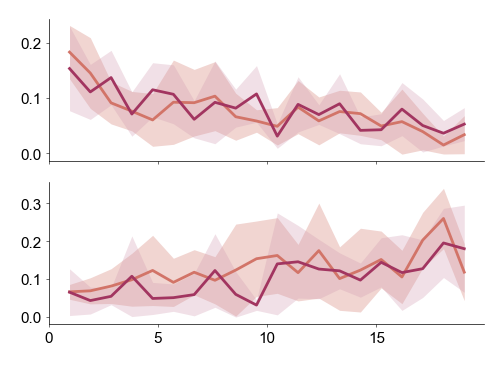

In [39]:
plot_sess = ["5", "52"]
lighten = [0, 0.5]
linewidth = [1.5, 1]

fig, ax = plt.subplots(2, 1, figsize=(2.5, 1.8))

for i, (a, lt) in enumerate(zip(plot_sess, lighten)):
    l = age_groups[a]
    loc = [binned_bhvs["loco"][s] for s in l]
    hdr = [binned_bhvs["raise"][s] for s in l]

    meanstd_line(ax[0], slice_times, loc, age_pal[a], lt)
    meanstd_line(ax[1], slice_times, hdr, age_pal[a], lt)

for a in ax:
    a.set_xticks([0, 5, 10, 15])
for a in ax[:-1]:
    a.set_xticklabels(["", "", "", ""])

    

plotter.finalize(fig, None)

#### rolling

0.000000          NaN
0.000556          NaN
0.001112          NaN
0.001668          NaN
0.002224          NaN
               ...   
19.967189    0.039969
19.967746    0.039969
19.968302    0.039969
19.968858    0.039969
19.969414    0.039969
Length: 35910, dtype: float64
0.000000          NaN
0.000556          NaN
0.001112          NaN
0.001668          NaN
0.002224          NaN
               ...   
19.967189    0.264506
19.967746    0.264321
19.968302    0.264136
19.968858    0.263935
19.969414    0.263735
Length: 35910, dtype: float64


/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


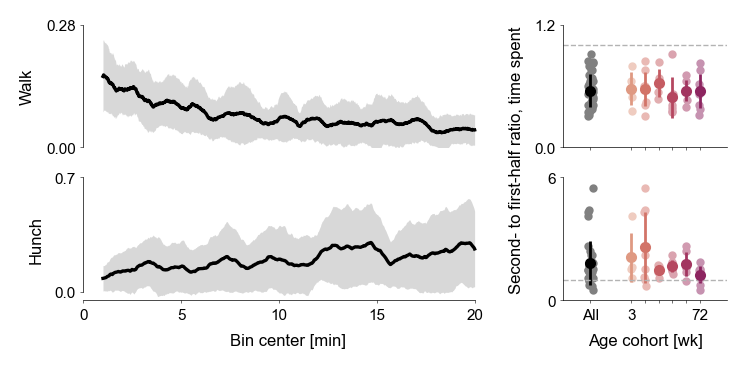

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/timecourse-bhvs.pdf')

In [213]:
plot_sess = ["24wk_m4"]
lighten = [0.5, 0.5]
linewidth = [1.2, 1]

fig, ax = plt.subplots(2, 2, figsize=(3.7, 1.8), width_ratios=[2.5, 1])
summ_ax = ax[:, 1]
time_ax = ax[:, 0]

ax = time_ax
for i, (s, lt, lw) in enumerate(zip(plot_sess, lighten, linewidth)):
    l = sessions
    loc = [bhv_masks["loco"][s][:min_nframes] for s in l]
    hdr = [bhv_masks["hunch"][s][:min_nframes] for s in l]
    a = s.split("_")[0].rstrip("wk")

    rolling_line(ax[0], frame_times, loc, 1800, 'k', lt, lw=lw)
    rolling_line(ax[1], frame_times, hdr, 1800, 'k', lt, lw=lw)

for a in ax:
    a.set_xticks([0, 5, 10, 15, 20])
    a.set_ylim(0, None)
for a in ax[:-1]:
    a.set_xticklabels(["", "", "", "", ""])
vu.nticks(ax, 2, x=False)
vu.round_limits(ax, 0.6, x=False, fixed_vmin=0)

ax[0].set_ylabel(bhv_names["loco"])
ax[1].set_ylabel(bhv_names["hunch"])
ax[-1].set_xlabel("Bin center [min]")
ax[0].set_xticks([])
ax[0].spines['bottom'].set_visible(False)
ax[1].set_yticks(ax[1].get_yticks())
ax[1].set_ylim(-0.05, ax[1].get_ylim()[1])
sns.despine(ax = ax[1], trim=True)

ax = summ_ax
half_rto = (
    lambda k: lambda s: bhv_masks[k][s][half_slices[1]].mean()
    / bhv_masks[k][s][half_slices[0]].mean()
)

groupstrip_kws = dict(
    groups=age_groups,
    order=ages,
    all_keys=sessions,
    summary_color='k',
    group_colors=age_pal,
    x_ofs=3,
)

group_and_summary_strips(
    ax[0],
    half_rto("loco"),
    **groupstrip_kws    
)

group_and_summary_strips(
    ax[1],
    half_rto("hunch"),
    **groupstrip_kws
)

for a in ax:
    a.axhline(1, color='.7', lw=0.5, ls="--")

ax[-1].set_xticklabels(["All"] + [ages[0]] + [""] * (len(ages) - 2) + [ages[-1]])
vu.nticks(ax, 2, x=False)
vu.round_limits(ax, 0.6, x=False, fixed_vmin=0)
ax[0].set_ylabel(" ")
ax[-1].set_xlabel("Age cohort [wk]")
plt.tight_layout()
ax[0].text(-0.33, -0.1, "Second- to first-half ratio, time spent", va = 'center', rotation=90, transform=ax[0].transAxes)


plotter.finalize(fig, 'timecourse-bhvs', despine=False, tight=False)

### 2. Time averaged pose from first and second half

In [178]:
ex_session = '24wk_m3'
mean_pose = {s: [obs_keypts[s][slc].mean(axis = 0) for slc in half_slices] for s in sessions}

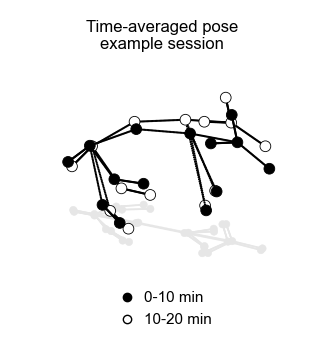

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/b-mean-pose-example.pdf')

In [118]:
fig = plt.figure(figsize = (1.6, 1.8))

kws = lambda fc, ec, ps, ls, label=None: dict(
    armature = arms,
    elev = 30, 
    rot = -70,
    colors = np.array([fc] * arms.n_kpts),
    line_colors = np.array([ec] * arms.n_kpts),
    point_size = ps,
    line_size = ls,
    label=label,
    point_kws = {'edgecolor': np.array([ec]*arms.n_kpts), 'linewidths': np.array([ls / 2]*arms.n_kpts)},
    boundary=False,
)
dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
plotdrop = lambda f, a, fc, ec, sm=1, lsm=1, shad=True, dropax=None, label=None, shadx=True, shady=True, shadz=True: [
    plot_mouse_3d(f, a, **kws(fc, ec, sm * 15, 1.5 * lsm, label))
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(dropz(f, -5), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shadz else None,
    plot_mouse_3d(dropy(f, 15), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shady else None,
    plot_mouse_3d(dropx(f, -5), dropax, **kws('.9' if shadx else 'w', '.9' if shadx else 'w', sm * 7, 1 * lsm)),
] if shad else [])

shad = fig.add_subplot(111, projection = '3d')
frnt = fig.add_subplot(111, projection = '3d')
back = fig.add_subplot(111, projection = '3d')

for a in [frnt, back]:
    a.sharex(shad)
    a.sharey(shad)
    a.sharez(shad)

plotdrop(mean_pose[ex_session][0], back, 'k', 'k', 1, 0.4, True, dropax=shad, shadx=False, shady=False)
plotdrop(mean_pose[ex_session][1], frnt, 'w', 'k', 1, 0.4, True, dropax=shad, shadx=False, shady=False)


frnt.plot([np.nan], [np.nan], [np.nan], 'o', mfc='k', mec='k', mew=0.5, ms = 3, label='0-10 min')
frnt.plot([np.nan], [np.nan], [np.nan], 'o', mfc='w', mec='k', mew=0.5, ms = 3, label='10-20 min')
vu.legend(frnt, loc = 'upper center', bbox_to_anchor = (0.5, 0.1), handletextpad=0.1)
frnt.text2D(0.5, 0.95, 'Time-averaged pose\nexample session', ha='center', va='center', transform=frnt.transAxes)


plotter.finalize(fig, 'b-mean-pose-example', despine = False)

In [179]:
not_hips = [i for i in range(14) if keypt_names[i] != 'hips']
pose_point_dists = {s: la.norm(np.diff(mean_pose[s], axis = 0)[0], axis = -1)[not_hips] for s in sessions}

/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of f

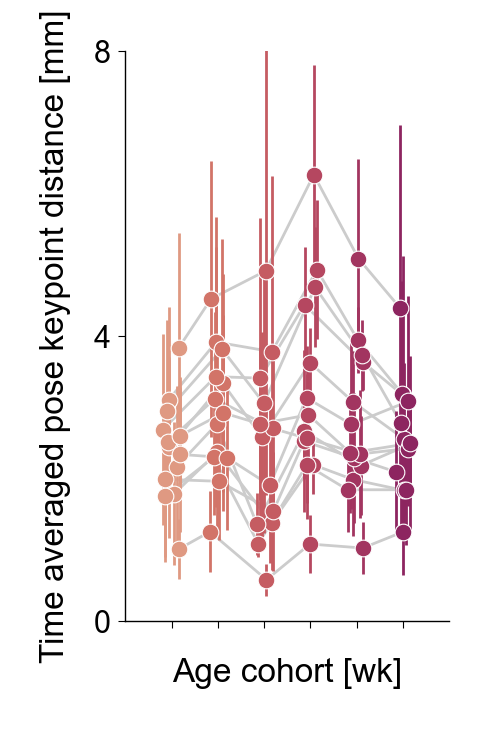

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/mean-pose-keypt-dists.pdf')

In [111]:

age_order = sorted(age_groups.keys(), key = int)

kp_groups = [('head', 'nose', 'l_ear', 'r_ear', 'shldr', 't_base', 'lr_knee', 'lr_foot', 'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot', 'back',)]
kp_group_colors = Colormap('turbo')(np.linspace(0.3, 1, len(kp_groups)))

fig, axes = plt.subplots(len(kp_groups), 1, figsize=(1.2, 1.8), sharex=True, sharey=True, dpi=200)
axes = [axes]

for ii, i in enumerate(not_hips):
    kp_name = arms.keypoint_names[i]
    
    kp_group = [g for g in kp_groups if kp_name in g][0]
    ax = axes[kp_groups.index(kp_group)]
    stripdata = agewise_stripstat(lambda s: pose_point_dists[s][ii], age_groups, age_order)
    meanline = [np.mean([a for a in l if a.size > 1]) for l in stripdata.values()]
    x = vu.jitter_points(np.arange(len(ages)), scale = 0.2)
    ax.plot(x, meanline, color='.8', lw=0.5, zorder = -1)
    vu.grouped_stripplot(
        stripdata,
        x = x,
        xticks = "",
        ax=ax,
        colors=age_pal,
        offset=False,
        jitter=0.05,
        # lighten_points=0.6,
        points = False,
        points_kw=dict(zorder = -2),
        errorbar_kw=dict(lw=0.5, elinewidth=0.5, mec='w', mew=0.2)
    )

ax.set_xticks(np.arange(len(ages)))
ax.set_xticklabels([''] * len(ages))
ax.set_xlim(-1, len(ages))
axes[0].set_ylabel('Time averaged pose keypoint distance [mm]')
ax.set_xlabel('Age cohort [wk]')

vu.nticks(ax, 3, x = False)
# vu.round_limits(ax, 1.4, x=False, fixed_vmin = 0)
ax.set_ylim(0, 8)


plotter.finalize(fig, 'mean-pose-keypt-dists', despine = False)
    

In [122]:
blscale_keypoints.keys()

dict_keys(['3wk_5bod_m1', '3wk_5bod_m0', '3wk_5bod_m2', '3wk_5bod_m3', '3wk_72bod_m1', '3wk_72bod_m0', '3wk_72bod_m2', '3wk_72bod_m3', '3wk_52bod_m1', '3wk_52bod_m0', '3wk_52bod_m2', '3wk_52bod_m3', '3wk_24bod_m1', '3wk_24bod_m0', '3wk_24bod_m2', '3wk_24bod_m3', '3wk_3bod_m1', '3wk_3bod_m0', '3wk_3bod_m2', '3wk_3bod_m3', '3wk_7bod_m1', '3wk_7bod_m0', '3wk_7bod_m2', '3wk_7bod_m3'])

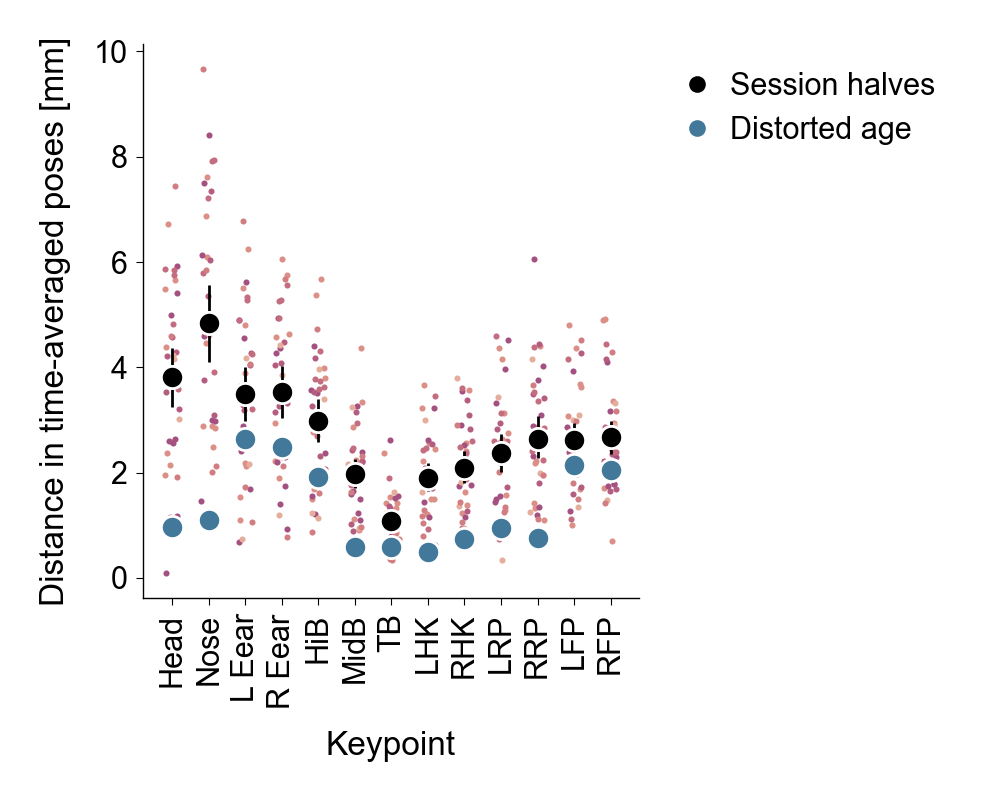

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/c-compare-to-blscale.pdf')

In [204]:
kp_order = ('head', 'nose', 'l_ear', 'r_ear', 'shldr', 'back', 't_base', 'lr_knee',  'rr_knee', 'lr_foot', 'rr_foot', 'lf_foot', 'rf_foot',)
kp_display_names = ['Head', 'Nose', "L Eear", "R Eear",        "HiB", "MidB", "TB",       "LHK", "RHK",         "LRP", 'RRP', 'LFP', 'RFP', ]


pose_point_dists = {s: la.norm(np.diff(mean_pose[s], axis = 0)[0], axis = -1) for s in sessions}
blscale_animals = [0, 1, 2, 3]
blscale_tgt = '52'
blscale_ref = '3'
blscale_means = {s: blscale_aligned.get_session(s).mean(axis = 0) for s in blscale_keypoints}

blscale_point_dists = {
    i: la.norm(blscale_means[f"{blscale_ref}wk_{blscale_tgt}bod_m{i}"] - blscale_means[f"{blscale_ref}wk_{blscale_ref}bod_m{i}"], axis = -1)
    for i in blscale_animals}
kp_idx = [arms.keypoint_names.inverse[k] for k in kp_order]
pose_point_dists = np.array([pose_point_dists[s][kp_idx] for s in sessions])
blscale_point_dists = np.array([blscale_point_dists[i][kp_idx] for i in blscale_animals])
age_order = sorted(age_groups.keys(), key = int)
sim_color = 0.5 * np.array(sim_pal['7']) + 0.5 * np.array(sim_pal['24'])

fig, ax = plt.subplots(1, 1, figsize=(1.6, 1.8), dpi=200)

for a, sl in age_groups.items():
    a_ixs = [sessions.index(s) for s in sl]
    vu.grouped_stripplot(
        {a: pose_point_dists[a_ixs].T},
        ax = ax,
        colors=age_pal[a],
        jitter=0.2,
        errorbar=False,
        lighten_points=0.2,
        points_kw = dict(ms = 1.1, mew=0,),
    )
vu.grouped_stripplot(
    pose_point_dists.T,
    ax = ax,
    colors='k',
    error=lambda x: vu.ci(x, level=0.95, n=1000),
    points=False,
    errorbar_kw=dict(elinewidth=0.5, mec='w', mew=0.5, ms = 4,),
)
vu.grouped_stripplot(
    blscale_point_dists.T,
    ax = ax,
    colors=sim_color,
    error=lambda x: vu.ci(x, level=0.95, n=1000),
    points=False,
    errorbar_kw=dict(elinewidth=0.5, mec='w', mew=0.5, ms = 4,),
)

ax.set_ylabel('Distance in time-averaged poses [mm]')
ax.set_xlabel("Keypoint")

ax.set_xticks(np.arange(len(kp_order)))
ax.set_xticklabels(kp_display_names, rotation=90)

ax.plot([np.nan], [np.nan], 'o', color='k', mew=0., ms = 3, label='Session halves')
ax.plot([np.nan], [np.nan], 'o', color=sim_color, mew=0., ms = 3, label='Distorted age')
vu.legend(ax, loc = 'upper left', bbox_to_anchor = (1, 1), handletextpad=0.1)


plotter.finalize(fig, 'c-compare-to-blscale', tight=False)

(14, 3)


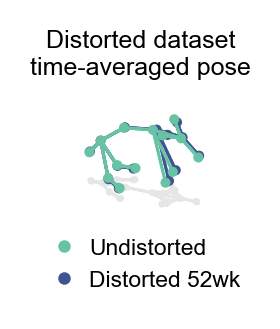

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/c-blscale-pose-example.pdf')

In [179]:
fig = plt.figure(figsize = (0.7, 0.7), dpi=150)

kws = lambda fc, ec, ps, ls, label=None: dict(
    armature = arms,
    elev = 30, 
    rot = -70,
    colors = np.array([fc] * arms.n_kpts),
    line_colors = np.array([ec] * arms.n_kpts),
    point_size = ps,
    line_size = ls,
    label=label,
    point_kws = {'edgecolor': np.array([ec]*arms.n_kpts), 'linewidths': np.array([ls / 2]*arms.n_kpts)},
    boundary=False,
)
dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
plotdrop = lambda f, a, fc, ec, sm=1, lsm=1, shad=True, dropax=None, label=None, shadx=True, shady=True, shadz=True: [
    plot_mouse_3d(f, a, **kws(fc, ec, sm * 15, 1.5 * lsm, label))
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(dropz(f, -5), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shadz else None,
    plot_mouse_3d(dropy(f, 15), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shady else None,
    plot_mouse_3d(dropx(f, -5), dropax, **kws('.9' if shadx else 'w', '.9' if shadx else 'w', sm * 7, 1 * lsm)),
] if shad else [])

shad = fig.add_subplot(111, projection = '3d')
frnt = fig.add_subplot(111, projection = '3d')
back = fig.add_subplot(111, projection = '3d')

for a in [frnt, back]:
    a.sharex(shad)
    a.sharey(shad)
    a.sharez(shad)

ex_sess_0 = f"{blscale_ref}wk_{blscale_ref}bod_m0"
ex_sess_1 = f"{blscale_ref}wk_{blscale_tgt}bod_m0"
print(blscale_means[ex_sess_0].shape)
plotdrop(blscale_means[ex_sess_0], back, sim_pal[blscale_ref], sim_pal[blscale_ref], 0.3, 0.4, True, dropax=shad, shadx=False, shady=False)
plotdrop(blscale_means[ex_sess_1], frnt, sim_pal[blscale_tgt], sim_pal[blscale_tgt], 0.3, 0.4, True, dropax=shad, shadx=False, shady=False)


plt.tight_layout()
frnt.plot([np.nan], [np.nan], [np.nan], 'o', color=sim_pal[blscale_ref], mew=0., ms = 3, label='Undistorted')
frnt.plot([np.nan], [np.nan], [np.nan], 'o', color=sim_pal[blscale_tgt], mew=0., ms = 3, label='Distorted 52wk')
vu.legend(frnt, loc = 'upper center', bbox_to_anchor = (0.5, 0.1), handletextpad=0.1)
frnt.text2D(0.5, 1.15, 'Distorted dataset\ntime-averaged pose', ha='center', va='center', transform=frnt.transAxes)

plotter.finalize(fig, 'c-blscale-pose-example', despine = False, tight=False)

### Time averaged pose within behaviors

#### Experiment

In [22]:
ex_session = '24wk_m3'
mean_pose = {s: [obs_keypts[s][slc].mean(axis = 0) for slc in half_slices] for s in sessions}
bmean_pose = {k: {s: [obs_keypts[s][slc][bhv_masks[k][s][slc]].mean(axis = 0) for slc in half_slices] for s in sessions}
             for k in bhv_keys}


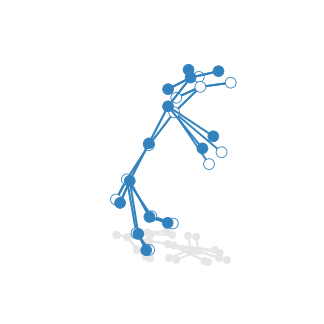

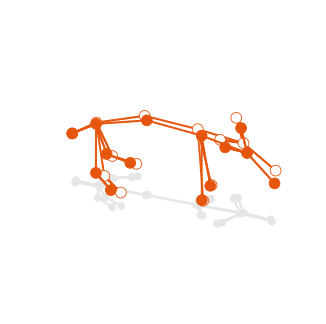

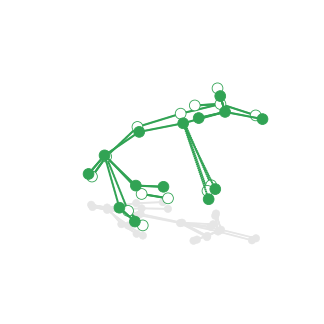

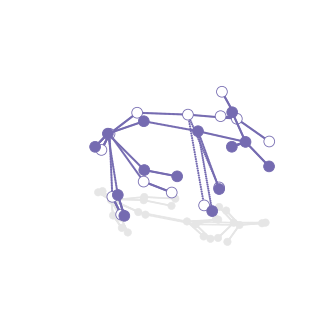

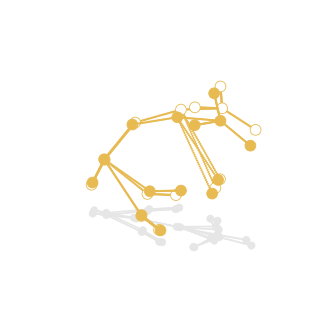

In [23]:

kws = lambda fc, ec, ps, ls, label=None: dict(
    armature = arms,
    elev = 30, 
    rot = -70,
    colors = np.array([fc] * arms.n_kpts),
    line_colors = np.array([ec] * arms.n_kpts),
    point_size = ps,
    line_size = ls,
    label=label,
    point_kws = {'edgecolor': np.array([ec]*arms.n_kpts), 'linewidths': np.array([ls / 2]*arms.n_kpts)},
    boundary=False,
)
dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
plotdrop = lambda f, a, fc, ec, sm=1, lsm=1, shad=True, dropax=None, label=None, shadx=True, shady=True, shadz=True: [
    plot_mouse_3d(f, a, **kws(fc, ec, sm * 15, 1.5 * lsm, label))
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(dropz(f, -5), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shadz else None,
    plot_mouse_3d(dropy(f, 15), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shady else None,
    plot_mouse_3d(dropx(f, -5), dropax, **kws('.9' if shadx else 'w', '.9' if shadx else 'w', sm * 7, 1 * lsm)),
] if shad else [])


for k in bhv_keys:
    fig = plt.figure(figsize = (1.6, 1.8))
    c = bhv_pal[k]

    shad = fig.add_subplot(111, projection = '3d')
    frnt = fig.add_subplot(111, projection = '3d')
    back = fig.add_subplot(111, projection = '3d')

    for a in [frnt, back]:
        a.sharex(shad)
        a.sharey(shad)
        a.sharez(shad)

    plotdrop(bmean_pose[k][ex_session][0], back, c, c, 1, 0.4, True, dropax=shad, shadx=False, shady=False)
    plotdrop(bmean_pose[k][ex_session][1], frnt, 'w', c, 1, 0.4, True, dropax=shad, shadx=False, shady=False)




    plotter.finalize(fig, None, despine = False)

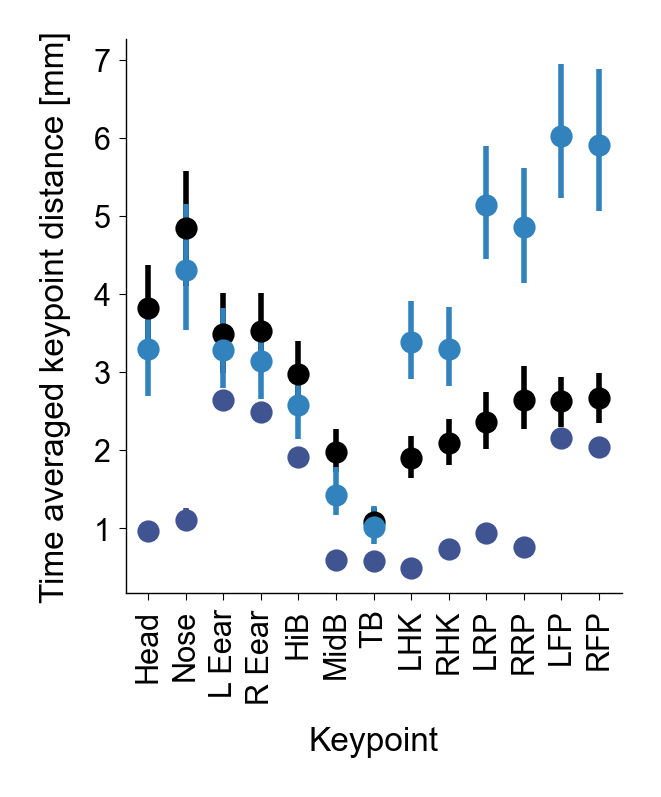

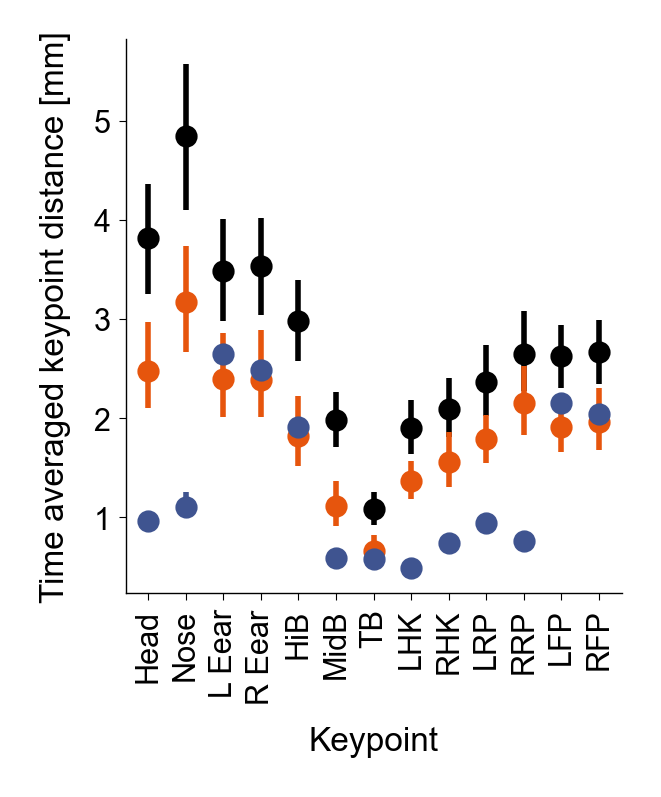

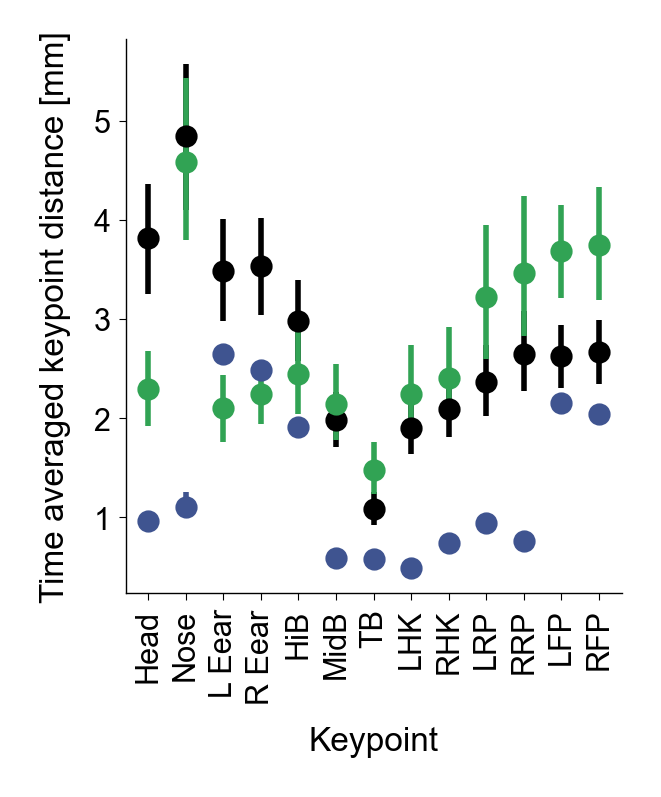

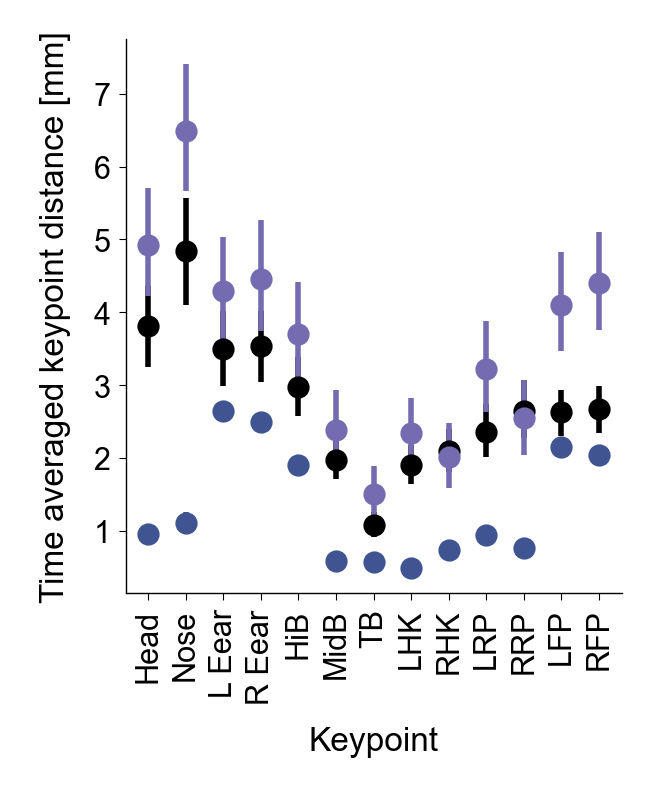

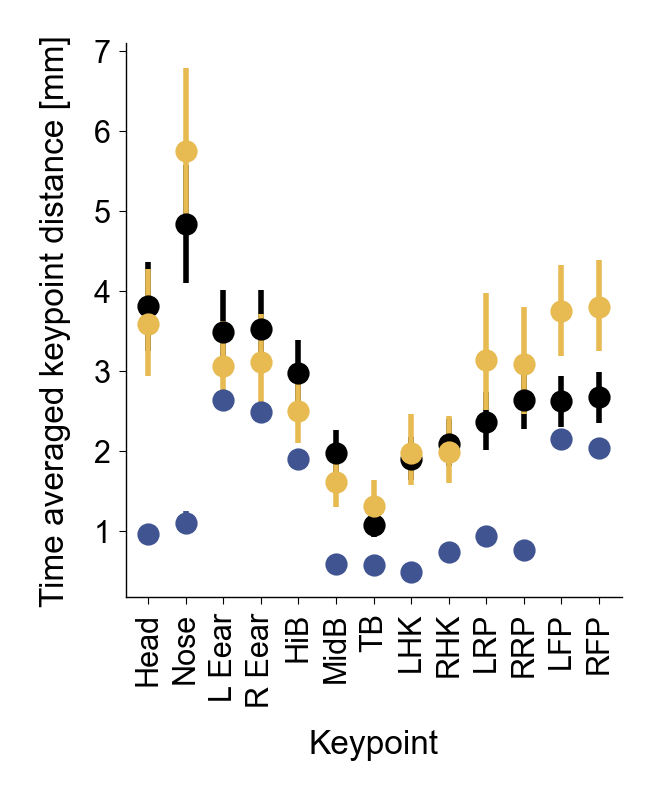

In [25]:
kp_order = ('head', 'nose', 'l_ear', 'r_ear', 'shldr', 'back', 't_base', 'lr_knee',  'rr_knee', 'lr_foot', 'rr_foot', 'lf_foot', 'rf_foot',)
kp_display_names = ['Head', 'Nose', "L Eear", "R Eear",        "HiB", "MidB", "TB",       "LHK", "RHK",         "LRP", 'RRP', 'LFP', 'RFP', ]

for k in bhv_keys:
    c = bhv_pal[k]
    pose_point_dists = {s: la.norm(np.diff(mean_pose[s], axis = 0)[0], axis = -1) for s in sessions}
    pose_point_dists_b = {s: la.norm(np.diff(bmean_pose[k][s], axis = 0)[0], axis = -1) for s in sessions}
    blscale_animals = [0, 1, 2, 3]
    blscale_tgt = '52'
    blscale_ref = '3'
    blscale_means = {s: blscale_aligned.get_session(s).mean(axis = 0) for s in blscale_keypoints}

    blscale_point_dists = {
        i: la.norm(blscale_means[f"{blscale_ref}wk_{blscale_tgt}bod_m{i}"] - blscale_means[f"{blscale_ref}wk_{blscale_ref}bod_m{i}"], axis = -1)
        for i in blscale_animals}
    kp_idx = [arms.keypoint_names.inverse[k] for k in kp_order]
    pose_point_dists = np.array([pose_point_dists[s][kp_idx] for s in sessions])
    pose_point_dists_b = np.array([pose_point_dists_b[s][kp_idx] for s in sessions])
    blscale_point_dists = np.array([blscale_point_dists[i][kp_idx] for i in blscale_animals])
    age_order = sorted(age_groups.keys(), key = int)

    fig, ax = plt.subplots(1, 1, figsize=(1.6, 1.8), dpi=200)

    
    vu.grouped_stripplot(
        pose_point_dists.T,
        ax = ax,
        colors='k',
        error=lambda x: vu.ci(x, level=0.95, n=1000),
        points=False,
        errorbar=dict(elinewidth=0.5, mec='w', mew=0, ms = 2,),
    )
    vu.grouped_stripplot(
        pose_point_dists_b.T,
        ax = ax,
        colors=c,
        error=lambda x: vu.ci(x, level=0.95, n=1000),
        points=False,
        errorbar=dict(elinewidth=0.5, mec='w', mew=0, ms = 2,),
    )
    vu.grouped_stripplot(
        blscale_point_dists.T,
        ax = ax,
        colors=sim_pal[blscale_tgt],
        error=lambda x: vu.ci(x, level=0.95, n=1000),
        points=False,
        errorbar=dict(elinewidth=0.5, mec='w', mew=10, ms = 2,),
    )

    ax.set_ylabel('Time averaged keypoint distance [mm]')
    ax.set_xlabel("Keypoint")

    ax.set_xticks(np.arange(len(kp_order)))
    ax.set_xticklabels(kp_display_names, rotation=90)


    plotter.finalize(fig, None, tight=False)

#### Experiment: GMM

In [30]:
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from shape_norm.io.utils import stack_dict

kpts_feats, kpts_slices  = stack_dict(obs_keypts)
kpts_pc = PCA(n_components=13)
kpts_pc.fit(kpts_feats.reshape([-1, arms.n_kpts * 3])[::1000])
kpts_pcfeat = kpts_pc.transform(kpts_feats.reshape([-1, arms.n_kpts * 3]))


In [45]:
ncl = 8
gmm = GaussianMixture(n_components=ncl, random_state=0)
gmm.fit(kpts_pcfeat[::1000])
kpts_clusts = gmm.predict(kpts_pcfeat)
print(dict(zip(*np.unique(kpts_clusts, return_counts=True))))
clust_masks = {s: np.stack([kpts_clusts[kpts_slices[s]] == c for c in range(ncl)], axis = -1) for s in sessions}

{0: 181214, 1: 210305, 2: 185174, 3: 83242, 4: 61752, 5: 275540, 6: 205231, 7: 90636}


/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_46088/227739525.py:3: RuntimeWarning: Mean of empty slice.
  cmean_pose = {cl: {s: [obs_keypts[s][slc][clust_masks[s][slc][:, cl]].mean(axis = 0) for slc in half_slices] for s in sessions}
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


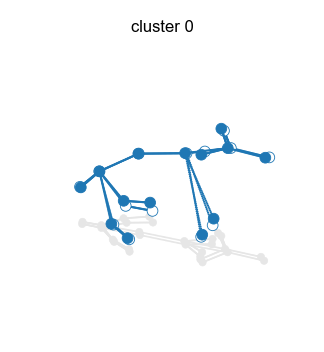

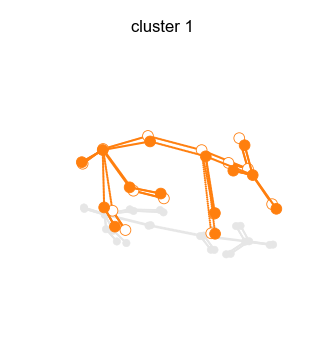

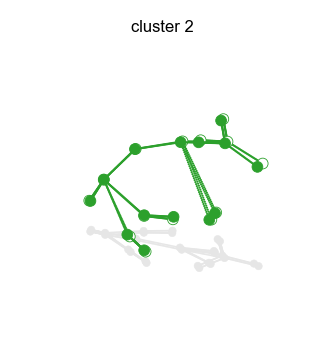

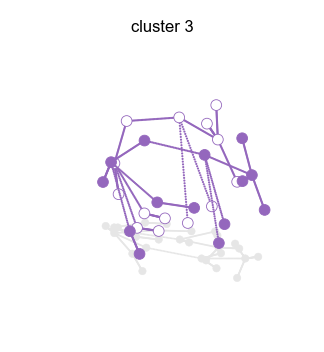

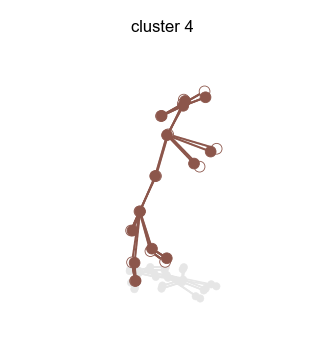

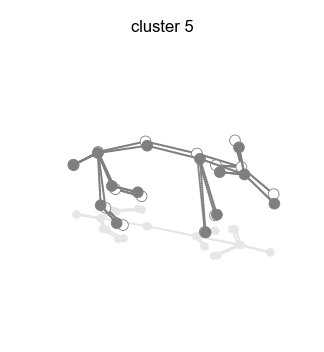

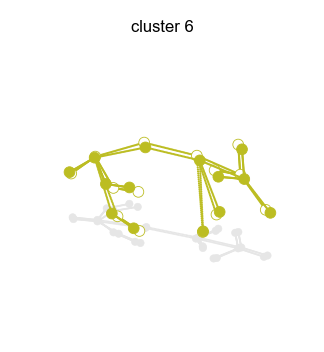

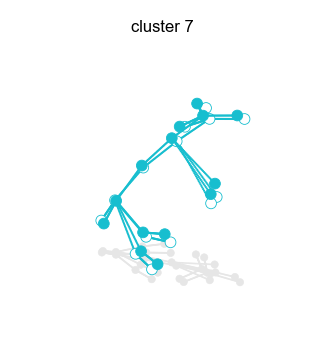

In [46]:
ex_session = '24wk_m3'
mean_pose = {s: [obs_keypts[s][slc].mean(axis = 0) for slc in half_slices] for s in sessions}
cmean_pose = {cl: {s: [obs_keypts[s][slc][clust_masks[s][slc][:, cl]].mean(axis = 0) for slc in half_slices] for s in sessions}
             for cl in range(ncl)}

kws = lambda fc, ec, ps, ls, label=None: dict(
    armature = arms,
    elev = 30, 
    rot = -70,
    colors = np.array([fc] * arms.n_kpts),
    line_colors = np.array([ec] * arms.n_kpts),
    point_size = ps,
    line_size = ls,
    label=label,
    point_kws = {'edgecolor': np.array([ec]*arms.n_kpts), 'linewidths': np.array([ls / 2]*arms.n_kpts)},
    boundary=False,
)
dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
plotdrop = lambda f, a, fc, ec, sm=1, lsm=1, shad=True, dropax=None, label=None, shadx=True, shady=True, shadz=True: [
    plot_mouse_3d(f, a, **kws(fc, ec, sm * 15, 1.5 * lsm, label))
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(dropz(f, -5), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shadz else None,
    plot_mouse_3d(dropy(f, 15), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shady else None,
    plot_mouse_3d(dropx(f, -5), dropax, **kws('.9' if shadx else 'w', '.9' if shadx else 'w', sm * 7, 1 * lsm)),
] if shad else [])

clust_pal = Colormap('tab10')(np.linspace(0, 1, ncl))
for cl in range(ncl):
    fig = plt.figure(figsize = (1.6, 1.8))
    c = clust_pal[cl]

    shad = fig.add_subplot(111, projection = '3d')
    frnt = fig.add_subplot(111, projection = '3d')
    back = fig.add_subplot(111, projection = '3d')

    for a in [frnt, back]:
        a.sharex(shad)
        a.sharey(shad)
        a.sharez(shad)

    plotdrop(cmean_pose[cl][ex_session][0], back, c, c, 1, 0.4, True, dropax=shad, shadx=False, shady=False)
    plotdrop(cmean_pose[cl][ex_session][1], frnt, 'w', c, 1, 0.4, True, dropax=shad, shadx=False, shady=False)
    frnt.set_title(f"cluster {cl}")




    plotter.finalize(fig, None, despine = False)

CLUSTER: 0
[[2.99787939 6.4742235  2.00910469 1.79581297 0.94951019 0.86734011
  0.47537627 0.33427337 0.72210938 0.68800379 1.26886195 3.07719287
  3.35084595]
 [2.98698788 4.87605399 3.54285906 2.21634407 2.61988482 1.48554297
  1.70697458 1.71982345 4.20996298 2.58013469 6.47136345 1.74310686
  3.95860813]
 [0.82995985 2.27080385 1.69262499 1.29583228 1.5735305  1.91040294
  0.92472502 2.82712181 4.14850374 3.1146655  4.44180478 4.27098768
  4.36180555]
 [2.10740763 2.73027956 2.14324632 1.09447992 1.39387793 0.99376895
  0.16407439 2.75157218 1.49896776 2.7831143  1.74611032 1.40418397
  0.87526143]
 [2.93020747 4.53694441 2.50072338 1.83145975 1.98621764 1.32880631
  0.25761097 1.48472212 2.80907092 1.6331864  3.05163044 2.53413504
  1.81121988]
 [0.9845083  1.43487265 0.87394638 0.7189029  0.63748658 0.58185167
  0.31284636 1.95973309 2.40997892 3.12602503 3.70734295 0.96123493
  1.2364996 ]
 [3.88555835 6.24835341 3.01296384 2.50188869 1.48913208 0.82730064
  0.52900065 2.065129

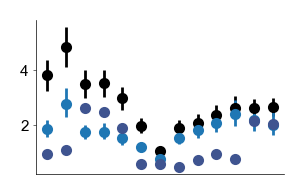

CLUSTER: 1
[[3.43928196 3.9788961  2.71973716 2.96284494 2.43362244 1.50206195
  0.72082376 1.30206358 1.84669473 1.22434265 2.17143084 1.34744473
  3.19318803]
 [6.00979319 6.31195053 6.21703284 6.3359581  5.4710009  3.69687304
  3.18069676 4.24496067 1.3290676  5.4587621  2.53169316 3.67060827
  4.29130995]
 [3.69167803 4.07067457 3.47777813 3.94632686 3.1711536  1.50286223
  1.92746592 1.19946768 4.74946841 1.24611553 6.22988023 1.49788153
  2.18303269]
 [2.5411894  3.61464659 3.36575809 1.70532213 2.19694391 1.67094655
  0.58983423 1.42148825 3.12141806 1.34835867 3.6618062  1.33735243
  3.41257471]
 [2.03388754 2.7527994  1.71172585 2.37735314 1.65887575 1.17448887
  0.38852071 1.25597292 2.45204461 1.24173927 2.86856073 1.61884318
  2.480222  ]
 [1.37730315 1.58134205 1.74527971 1.18780402 1.31979303 1.23422663
  0.78250485 2.06025454 0.92763675 3.34506273 2.42648957 1.31172242
  1.73338221]
 [0.84789498 1.39537121 0.76231296 0.52243906 0.59334503 0.84275789
  0.82038412 0.988486

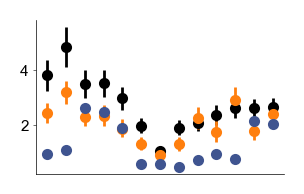

CLUSTER: 2
[[ 1.69223975  3.73702024  0.27111163  1.79829133  0.81211019  0.84572895
   1.09018196  2.40153958  3.01500228  4.17810077  4.56313359  2.47421616
   1.93900118]
 [ 3.77740381  6.76073264  5.93952701  1.47779934  4.83207922  6.12069253
   6.0894228   8.5003557  10.05635321 13.9126723  16.03083386  4.98824471
   8.58693461]
 [ 4.19642672  6.12749426  3.69930999  3.75482955  2.70034292  1.44449772
   3.33783969  3.57386333  1.73757836  4.21987771  2.99471477  4.29438126
   3.33365867]
 [ 1.29009533  2.93684293  1.43197271  1.93183946  1.43947317  1.41365573
   0.69397735  2.85193919  1.95475391  4.17766253  3.29116709  2.86089693
   3.65477004]
 [ 2.08371857  4.38040157  1.08354659  1.1482582   0.87977115  0.60446128
   0.75705647  1.49436149  0.81383696  2.13362744  1.49049547  1.65980142
   1.36174228]
 [ 2.19861152  3.22451681  3.32673938  3.11635518  2.94957726  3.05056809
   3.73999333  3.23826657  6.44931773  6.00680261 10.92062302  6.66987566
   6.46139841]
 [ 0.909643

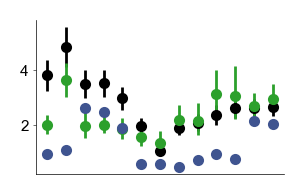

CLUSTER: 3
[[ 1.47472218  1.62650203  1.51736132  2.24276667  1.53232397  1.30978522
   2.03825008  3.71848378  2.85714773  6.26618532  5.40647674  4.22836723
   5.29211055]
 [ 6.82470579  8.78759428  5.9796075   6.6039446   5.49594452  4.99104845
   5.32131315  7.11014298  2.91794091 11.27486822  5.81603138  8.40175429
  10.43703436]
 [ 3.11717595  7.65572514  1.60394522  2.11193386  2.14336176  3.87096907
   3.07011196  2.68936446  2.80467347  1.25511143  4.60509101  5.64911488
   6.48471656]
 [ 1.969269    3.17199813  2.2544976   2.08966606  2.02517018  1.90291099
   1.72981189  1.25177641  0.88349921  1.59377004  1.48585659  1.5843115
   1.89415081]
 [ 3.66685883  5.5243286   2.84231354  3.67264702  3.37974093  2.63279037
   2.12252346  1.08098287  1.98645579  2.50939046  3.17751944  4.67367748
   5.43063662]
 [ 3.01705541  3.80200438  3.28679907  2.82610073  3.74159328  3.54235824
   3.55405773  5.25554329  6.93308127  9.30506077 11.61027115  7.69584608
   6.69788855]
 [ 3.7698825

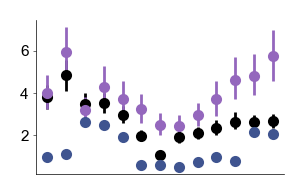

CLUSTER: 4
[[ 2.7547615   3.7487719   4.27643145  1.31687862  1.82920979  0.77408278
   0.42217726  1.57434663  1.99448906  2.2049751   2.56148181  5.33416718
   2.91269426]
 [ 2.33579067  3.82483488  1.61928987  2.70971988  0.98735135  1.65468447
   1.55864378  2.59867995  3.36811722  2.83099461  4.57165992  2.8126287
   2.41822519]
 [ 7.99560832 10.42356231  7.15282814  6.21898     4.97778027  1.93503346
   2.26357505  5.39326826  3.10212492  8.36096371  6.27295414  7.66414519
   5.84343619]
 [ 2.86809704  3.83629084  2.02810998  3.17690023  1.95763645  1.23442275
   0.92467869  3.14929794  1.54526042  4.70449863  2.79943337  2.93014578
   4.19975749]
 [ 1.0690549   1.46010792  1.49374416  1.14591388  0.77570843  0.44939439
   0.17884729  1.20905619  1.2374285   1.9135276   1.7343933   2.13846636
   2.9639458 ]
 [ 4.55089569  5.57211606  3.43851264  5.82864456  3.41437697  1.48356856
   1.75910832  2.49542059  1.3868462   5.76715304  4.31674674  3.69630457
   5.96613728]
 [ 1.7377566

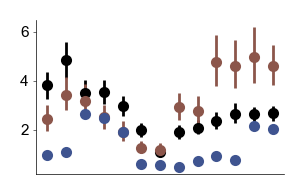

CLUSTER: 5
[[ 1.56550559  1.57135119  1.31402602  1.77398952  1.37525674  0.99180887
   0.69406697  0.42979244  0.6989525   0.57500081  1.00992854  0.93403139
   1.61083303]
 [ 1.63596791  3.39327666  2.1671025   3.20752834  1.34319395  1.30912474
   0.83501992  2.03896963  1.0283348   1.74239273  3.84867516  5.50756914
   6.92619352]
 [16.22531304 22.28319311 12.70402598 20.15999039 15.1855868  13.28648451
  11.70982822  8.77187798 18.48157598 19.68275334 28.25238823 18.25534807
  18.64431925]
 [ 0.74443452  0.80186964  0.80357231  0.6609532   0.52895125  0.46964017
   0.15881386  0.62466449  0.92545179  0.7148031   0.94842516  0.54792885
   0.56165217]
 [ 2.5636621   2.97011572  2.2976534   2.62273063  1.91604989  1.32358104
   0.61279249  0.67227365  2.23127929  0.6396497   2.81061804  1.57323473
   1.46065491]
 [15.94416633 22.07292117 18.89107829 14.5867447  12.69504444 10.05024242
   7.76741232 16.87845343  9.9775494  24.05634211 13.45613971 12.34804457
  14.48666723]
 [ 6.282581

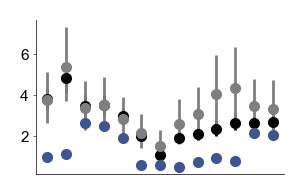

CLUSTER: 6
[[ 0.83367089  1.08444136  0.62492997  0.84986435  0.59245811  0.41431265
   0.37010015  0.74230821  0.74425235  0.70342863  0.56338462  1.3061124
   1.75258077]
 [ 3.79655717  4.1834368   4.38141002  3.92093336  3.57446363  2.8430803
   1.80208816  0.79823487  1.98762678  1.49555472  1.56912666  3.67913828
   2.62052845]
 [ 0.93197837  0.88605503  1.39458689  0.72286605  1.05455641  0.94039283
   0.86304479  2.33853686  1.50053746  2.87192139  1.43435767  2.27925235
   2.16693926]
 [ 2.83802869  3.44084372  1.79813524  3.45230667  2.55054514  2.25646118
   1.08791868  4.91588471  2.56351832  5.68052208  3.09673677  2.80094242
   1.79898781]
 [ 5.62700398  8.49228563  4.04858498  4.67964467  2.48699125  0.75086133
   0.7177088   2.05935685  2.59794577  2.63420508  3.37520986  3.18591354
   4.75793213]
 [ 3.11846701  4.42638985  2.64914856  2.8506483   1.8844517   0.59958279
   0.71393499  1.61149929  1.13604492  1.61373943  1.96914811  1.45640631
   1.7587684 ]
 [ 5.18913111

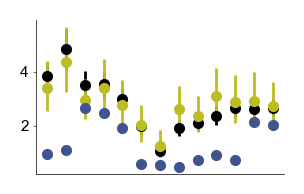

CLUSTER: 7
[[ 1.3273169   1.89406826  1.97140538  2.89485459  0.81599128  0.42921313
   0.9537518   4.40101285  3.28523818  6.67978427  5.15308549  5.67206714
   3.555074  ]
 [ 2.93336011  4.57287711  2.53683654  1.67787002  1.02991957  0.35854879
   0.80975838  3.00311108  1.48063246  2.69323892  1.41664112  6.50813245
   1.67527904]
 [ 0.8094168   2.84083721  2.17431748  1.57913284  2.44698047  2.65418217
   0.53203214  2.13696538  1.38062088  3.01257308  1.10015281  4.96112846
   3.25450521]
 [ 1.2094438   2.10020259  1.33207867  1.41800175  0.78284376  0.83756833
   0.49768584  1.33499262  1.80322667  1.06680938  2.7912227   3.99080877
   2.47786397]
 [ 3.7582022   5.37599238  2.96396701  3.06953395  2.383356    1.49073271
   0.79979569  2.33054928  0.50553002  3.05449106  1.63056093  4.24386538
   1.97864113]
 [ 5.51446703  6.96809898  5.38594713  6.58762403  5.33204029  3.32975486
   2.43420657  1.54447269  4.98446625  4.11838072  7.11357149  9.78502801
  11.00950947]
 [ 2.619076

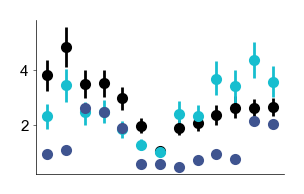

In [51]:
kp_order = ('head', 'nose', 'l_ear', 'r_ear', 'shldr', 'back', 't_base', 'lr_knee',  'rr_knee', 'lr_foot', 'rr_foot', 'lf_foot', 'rf_foot',)
kp_display_names = ['Head', 'Nose', "L Eear", "R Eear",        "HiB", "MidB", "TB",       "LHK", "RHK",         "LRP", 'RRP', 'LFP', 'RFP', ]
clust_pal = Colormap('tab10')(np.linspace(0, 1, ncl))
for cl in range(ncl):
    c = clust_pal[cl]
    pose_point_dists = {s: la.norm(np.diff(mean_pose[s], axis = 0)[0], axis = -1) for s in sessions}
    pose_point_dists_c = {s: la.norm(np.diff(cmean_pose[cl][s], axis = 0)[0], axis = -1) for s in sessions if np.any(clust_masks[s][:, cl])}
    blscale_animals = [0, 1, 2, 3]
    blscale_tgt = '52'
    blscale_ref = '3'
    blscale_means = {s: blscale_aligned.get_session(s).mean(axis = 0) for s in blscale_keypoints}

    blscale_point_dists = {
        i: la.norm(blscale_means[f"{blscale_ref}wk_{blscale_tgt}bod_m{i}"] - blscale_means[f"{blscale_ref}wk_{blscale_ref}bod_m{i}"], axis = -1)
        for i in blscale_animals}
    kp_idx = [arms.keypoint_names.inverse[k] for k in kp_order]
    pose_point_dists = np.array([pose_point_dists[s][kp_idx] for s in sessions])
    pose_point_dists_c = np.array([pose_point_dists_c[s][kp_idx] for s in sessions if np.all(np.isfinite(pose_point_dists_c[s]))])
    blscale_point_dists = np.array([blscale_point_dists[i][kp_idx] for i in blscale_animals])
    age_order = sorted(age_groups.keys(), key = int)

    fig, ax = plt.subplots(1, 1, figsize=(1.6, 1.), dpi=100)

    
    vu.grouped_stripplot(
        pose_point_dists.T,
        ax = ax,
        colors='k',
        error=lambda x: vu.ci(x, level=0.95, n=1000),
        points=False,
        errorbar=dict(elinewidth=0.5, mec='w', mew=0, ms = 2,),
    )
    print("CLUSTER:", cl)
    print(pose_point_dists_c)
    vu.grouped_stripplot(
        pose_point_dists_c.T,
        ax = ax,
        colors=c,
        error=lambda x: vu.ci(x, level=0.95, n=1000),
        points=False,
        errorbar=dict(elinewidth=0.5, mec='w', mew=0, ms = 2,),
    )
    vu.grouped_stripplot(
        blscale_point_dists.T,
        ax = ax,
        colors=sim_pal[blscale_tgt],
        error=lambda x: vu.ci(x, level=0.95, n=1000),
        points=False,
        errorbar=dict(elinewidth=0.5, mec='w', mew=10, ms = 2,),
    )

    
    ax.set_xticks([])


    plotter.finalize(fig, None, tight=False)

#### Experiment: variance / prediction of bone lenghts / joint angles

In [80]:
frame_bl = {s: la.norm(bone_locations(obs_keypts[s], arms), axis = -1) for s in sessions}
frame_ja = {s: np.stack([joint_angles(obs_keypts[s], i) for i in range(len(joints))], axis = -1) for s in sessions}

half_bl = np.array([[frame_bl[s][half_slices[0]].mean(axis = 0), frame_bl[s][half_slices[1]].mean(axis = 0)] for s in sessions])
half_ja = np.array([[frame_ja[s][half_slices[0]].mean(axis = 0), frame_ja[s][half_slices[1]].mean(axis = 0)] for s in sessions])

ref_session = "3wk_m0"
bhv_n = {k: {s: bhv_masks[k][s][half_slices[0]].sum() for s in sessions} for k in bhv_keys}
rng = np.random.default_rng(32)
frame_samp = {
    s: [np.concatenate(
        [
            # choose indices relative to `slc` where `s` has behavior `k`
            rng.choice(np.where(bhv_masks[k][s][slc])[0], size = bhv_n[k][s], replace=True)
            for k in bhv_keys
        ]
    ) for i_slc, slc in enumerate(half_slices)]
    for s in sessions
}
samp_bl = np.array([[frame_bl[s][slc][frame_samp[s][i_slc]].mean(axis = 0) for i_slc, slc in enumerate(half_slices)] for s in sessions])
samp_ja = np.array([[frame_ja[s][slc][frame_samp[s][i_slc]].mean(axis = 0) for i_slc, slc in enumerate(half_slices)] for s in sessions])

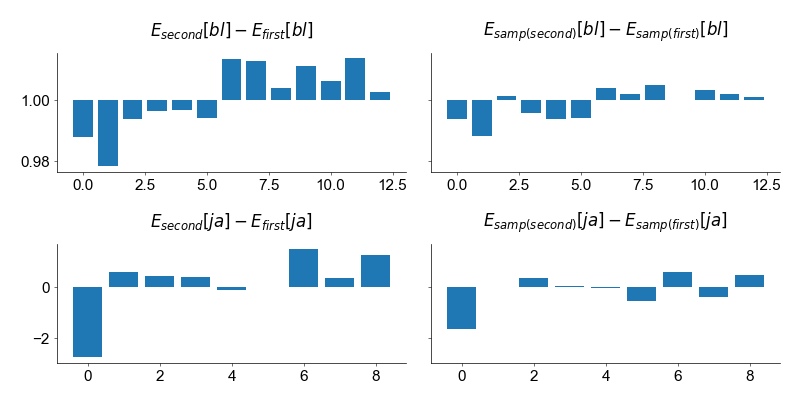

In [87]:

fig, ax = plt.subplots(2, 2, figsize = (4, 2), sharey='row')

half_bl_change = half_bl[:, 1, :] / half_bl[:, 0, :]
samp_bl_change = samp_bl[:, 1, :] / samp_bl[:, 0, :]
ax[0, 0].bar(range(13), half_bl_change.mean(axis = 0) - 1, bottom = 1)
ax[0, 0].set_title("$E_{second}[bl] - E_{first}[bl]$")

ax[0, 1].bar(range(13), samp_bl_change.mean(axis = 0) - 1, bottom = 1)
ax[0, 1].set_title("$E_{samp(second)}[bl] - E_{samp(first)}[bl]$")

half_ja_change = half_ja[:, 1, :] - half_ja[:, 0, :]
samp_ja_change = samp_ja[:, 1, :] - samp_ja[:, 0, :]
ax[1, 0].bar(range(9), half_ja_change.mean(axis = 0))
ax[1, 0].set_title("$E_{second}[ja] - E_{first}[ja]$")

ax[1, 1].bar(range(9), samp_ja_change.mean(axis = 0))
ax[1, 1].set_title("$E_{samp(second)}[ja] - E_{samp(first)}[ja]$")

plotter.finalize(fig, None)

#### plot: bone lengths with and without resample by group

In [90]:
_bone_lengths = lambda kpts, arms: jnp.linalg.norm(
    kpts[..., arms.bones[:, 0], :] - kpts[..., arms.bones[:, 1], :], axis=-1
)
cos = lambda a, b, **k: (a * b).sum(**k) / jnp.sqrt((a * a).sum(**k) * (b * b).sum(**k))
_joint_angles = lambda kpts, joint_kp_ixs: np.array([(180/np.pi) * np.arccos(np.clip(cos(
    kpts[:, c, :] - kpts[:, p, :],
    kpts[:, g, :] - kpts[:, p, :],
axis = -1), -1, 1)) for c, p, g in joint_kp_ixs]).T

frame_bl = {s: _bone_lengths(obs_keypts[s], arms)for s in sessions}
frame_ja = {s: _joint_angles(obs_keypts[s], joint_kp_ixs) for s in sessions}

half_bl = np.array([[frame_bl[s][half_slices[0]].mean(axis = 0), frame_bl[s][half_slices[1]].mean(axis = 0)] for s in sessions])
half_ja = np.array([[frame_ja[s][half_slices[0]].mean(axis = 0), frame_ja[s][half_slices[1]].mean(axis = 0)] for s in sessions])

ref_session = "3wk_m0"
bhv_n = {k: {s: bhv_masks[k][s][half_slices[0]].sum() for s in sessions} for k in bhv_keys}
rng = np.random.default_rng(32)
frame_samp = {
    s: [np.concatenate(
        [
            # choose indices relative to `slc` where `s` has behavior `k`
            rng.choice(np.where(bhv_masks[k][s][slc])[0], size = bhv_n[k][s], replace=True)
            for k in bhv_keys
        ]
    ) for i_slc, slc in enumerate(half_slices)]
    for s in sessions
}
samp_bl = np.array([[frame_bl[s][slc][frame_samp[s][i_slc]].mean(axis = 0) for i_slc, slc in enumerate(half_slices)] for s in sessions])
samp_ja = np.array([[frame_ja[s][slc][frame_samp[s][i_slc]].mean(axis = 0) for i_slc, slc in enumerate(half_slices)] for s in sessions])


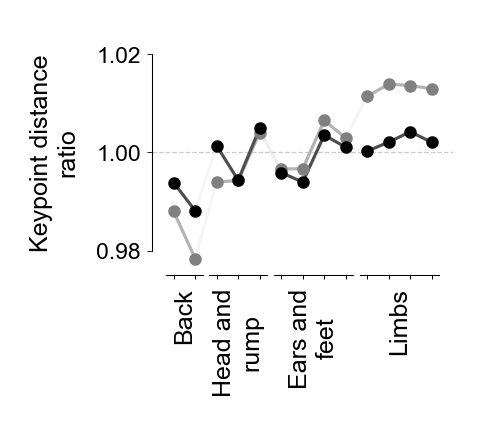

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/resamp-bl.pdf')

In [155]:
half_bl_change = (half_bl[:, 1, bone_ix_order] / half_bl[:, 0, bone_ix_order]).mean(axis = 0)
samp_bl_change = (samp_bl[:, 1, bone_ix_order] / samp_bl[:, 0, bone_ix_order]).mean(axis = 0)



fig, ax = plt.subplots(1, 1, figsize = (1.6, 1.), dpi=150)
ax.plot(half_bl_change, '-', color = '.9', lw = 0.75, alpha = 0.4, zorder = -2)
ax.plot(samp_bl_change, '-', color = '.9', lw = 0.75, alpha = 0.4, zorder = -2)
for bone_group in bone_groups:
    g = np.arange(bone_group[0], bone_group[1] + 1)
    ax.plot(g, half_bl_change[g], '-', color = '.7', lw = 0.75, label = 'True\nsessions')
    ax.plot(g, samp_bl_change[g], '-', color = '.3', lw = 0.75, label = 'Matched\nbehavior')

ax.plot(half_bl_change[:], 'o', color = '.5', ms = 2)
ax.plot(samp_bl_change[:], 'o', color = 'k', ms = 2)
# vu.legend(ax, vu.unique_handles(ax), bbox_to_anchor = (1, 0.5))

ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_ylabel("Keypoint distance\nratio")
ax.set_ylim(1 - 0.025, 1.025)
ax.set_yticks([1 - 0.02, 1, 1 + 0.02])
ax.set_xlim(-1, 13)
ax.axhline(1, color='.8', ls = '--', lw=0.3, zorder=-1)
sns.despine(ax = ax, trim = True, bottom=True)

plt.tight_layout()

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax)
for bg, n in zip(bone_groups, bone_group_names):
    ax.add_artist(
        mpl.lines.Line2D(
            [bg[0] - 0.35, bg[1] + 0.35],
            [ymin, ymin],
            color="k",
            lw=0.25,
            clip_on=False,
        )
    )
    ax.add_artist(
        mpl.text.Text(
            (bg[0] + bg[1]) / 2,
            -0.05,
            n,
            ha="center",
            va="top",
            clip_on=False,
            fontsize=6,
            rotation=90,
            transform=mpl.transforms.blended_transform_factory(
                ax.transData, ax.transAxes
            ),
        )
    )

# convert inches to data coordinates
# (1 mm = 0.0393701 inches)
mm_to_data_y = ax.transData.inverted().transform([0, fig.dpi_scale_trans.transform((0, 0.039))[1]])[1] - ax.transData.inverted().transform([0, fig.dpi_scale_trans.transform((0, 0))[1]])[1]

for x in range(0, len(bone_names)):
    ax.add_artist(
        mpl.lines.Line2D(
            [x, x],
            [ymin, ymin-mm_to_data_y*0.3],
            color="k",
            lw=0.25,
            clip_on=False,
            solid_capstyle="butt",
        )
    )


plotter.finalize(fig, 'resamp-bl', tight=False, despine=False)

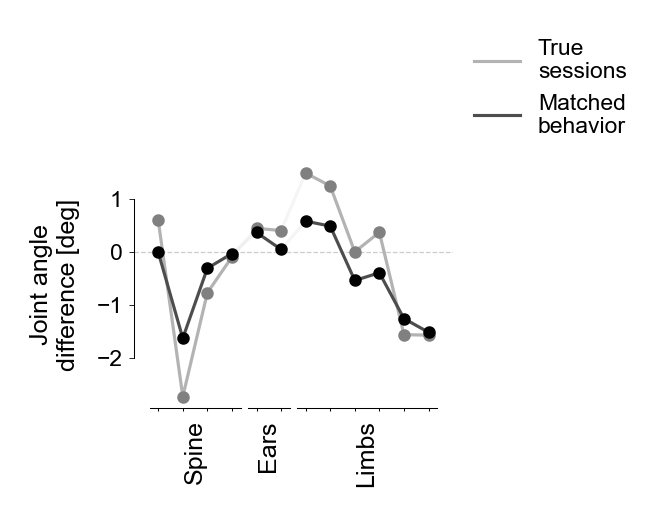

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/resamp-ja.pdf')

In [157]:
half_ja_change = (half_ja[:, 1, :] - half_ja[:, 0, :]).mean(axis = 0)
samp_ja_change = (samp_ja[:, 1, :] - samp_ja[:, 0, :]).mean(axis = 0)



fig, ax = plt.subplots(1, 1, figsize = (1.6, 1.), dpi=150)
ax.plot(half_ja_change, '-', color = '.9', lw = 0.75, alpha = 0.4, zorder = -2)
ax.plot(samp_ja_change, '-', color = '.9', lw = 0.75, alpha = 0.4, zorder = -2)
for joint_group in joint_groups:
    g = np.arange(joint_group[0], joint_group[1] + 1)
    ax.plot(g, half_ja_change[g], '-', color = '.7', lw = 0.75, label = 'True\nsessions')
    ax.plot(g, samp_ja_change[g], '-', color = '.3', lw = 0.75, label = 'Matched\nbehavior')

ax.plot(half_ja_change[:], 'o', color = '.5', ms = 2)
ax.plot(samp_ja_change[:], 'o', color = 'k', ms = 2)


ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_ylabel("Joint angle\ndifference [deg]")
# ax.set_ylim(1 - 0.025, 1.025)
# ax.set_yticks([1 - 0.02, 1, 1 + 0.02])
ax.set_xlim(-1, 12)
ax.axhline(0, color='.8', ls = '--', lw=0.3, zorder=-1)
sns.despine(ax = ax, trim = True, bottom=True)

plt.tight_layout()
vu.legend(ax, vu.unique_handles(ax), bbox_to_anchor = (1, 1.3))

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax)
for bg, n in zip(joint_groups, joint_group_names):
    ax.add_artist(
        mpl.lines.Line2D(
            [bg[0] - 0.35, bg[1] + 0.35],
            [ymin, ymin],
            color="k",
            lw=0.25,
            clip_on=False,
        )
    )
    ax.add_artist(
        mpl.text.Text(
            (bg[0] + bg[1]) / 2,
            -0.05,
            n,
            ha="center",
            va="top",
            clip_on=False,
            fontsize=6,
            rotation=90,
            transform=mpl.transforms.blended_transform_factory(
                ax.transData, ax.transAxes
            ),
        )
    )

# convert inches to data coordinates
# (1 mm = 0.0393701 inches)
mm_to_data_y = ax.transData.inverted().transform([0, fig.dpi_scale_trans.transform((0, 0.039))[1]])[1] - ax.transData.inverted().transform([0, fig.dpi_scale_trans.transform((0, 0))[1]])[1]

for x in range(0, len(joint_names)):
    ax.add_artist(
        mpl.lines.Line2D(
            [x, x],
            [ymin, ymin-mm_to_data_y*0.3],
            color="k",
            lw=0.25,
            clip_on=False,
            solid_capstyle="butt",
        )
    )


plotter.finalize(fig, 'resamp-ja', tight=False, despine=False)

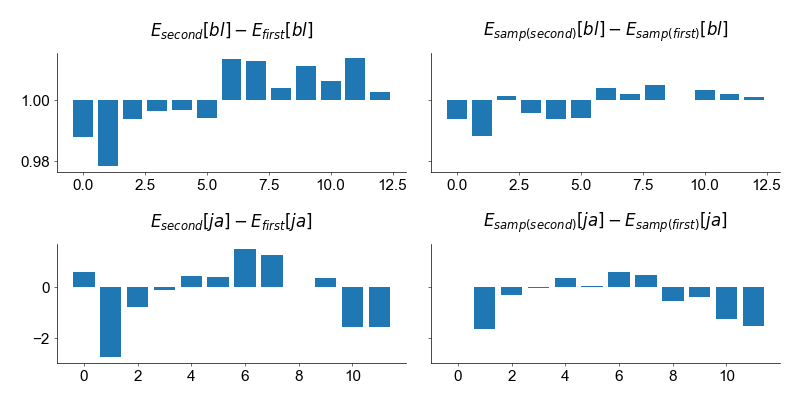

In [92]:
fig, ax = plt.subplots(2, 2, figsize = (4, 2), sharey='row')

half_bl_change = half_bl[:, 1, :] / half_bl[:, 0, :]
samp_bl_change = samp_bl[:, 1, :] / samp_bl[:, 0, :]
ax[0, 0].bar(range(13), half_bl_change.mean(axis = 0) - 1, bottom = 1)
ax[0, 0].set_title("$E_{second}[bl] - E_{first}[bl]$")

ax[0, 1].bar(range(13), samp_bl_change.mean(axis = 0) - 1, bottom = 1)
ax[0, 1].set_title("$E_{samp(second)}[bl] - E_{samp(first)}[bl]$")

half_ja_change = half_ja[:, 1, :] - half_ja[:, 0, :]
samp_ja_change = samp_ja[:, 1, :] - samp_ja[:, 0, :]
ax[1, 0].bar(range(12), half_ja_change.mean(axis = 0))
ax[1, 0].set_title("$E_{second}[ja] - E_{first}[ja]$")

ax[1, 1].bar(range(12), samp_ja_change.mean(axis = 0))
ax[1, 1].set_title("$E_{samp(second)}[ja] - E_{samp(first)}[ja]$")

plotter.finalize(fig, None)

### g. Behavior biases in distances and joint angles

In [207]:
bl = {
    s: la.norm(bone_locations(obs_keypts[s], arms), axis = -1)
    for s in sessions
}
ja = {
    s: np.stack([joint_angles(obs_keypts[s], i) for i in range(len(joints))], axis = -1)
    for s in sessions

}

In [215]:
plot_bhv = ['rear', 'loco',  'raise', 'turn', 'hunch', ]
plot_bones = ['Lower\nback', 'Forelimb\nmean', "Back\ncurvature\n[deg]"]
subsample = 10
all_bl = np.concatenate([bl[s] for s in sessions])
all_ja = np.concatenate([ja[s] for s in sessions])
null_mask = {s: np.ones(session_length[s], dtype = bool) for s in sessions}
all_masks = {
    k: np.concatenate([m[s] for s in sessions])
    for k, m in list(bhv_masks.items()) + [('none', null_mask)]
}
z_outliers = lambda x, z = 3: np.abs(scipy.stats.zscore(x)) < z
plot_data = [
    all_bl[:, bone_names.index('lo back')],
    all_bl[:, [bone_names.index('left forelimb'), bone_names.index('right forelimb')]].mean(axis = 1),
    180 - all_ja[:, joint_names.index('back')]
]
bone_dists = {k: [
    plot_data[i][z_outliers(plot_data[i]) & m]
    for i in range(len(plot_data))
] for k, m in all_masks.items()}

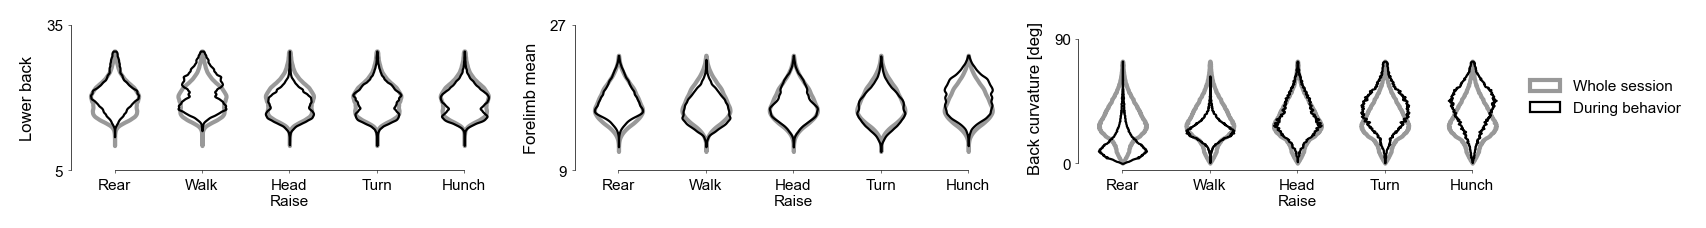

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/bone-bhv-examples.pdf')

In [217]:
fig, ax = plt.subplots(1, 3, figsize=(8.5, 1.1))
# ax[1, 1].set_axis_off()
ax = ax.T.ravel()[[0, 1, 2]]

kws = dict(
    bw = 0.2,
    x = np.arange(len(plot_bhv)),
    errorbar = False,
    jitter = False,
    thumb_bandwidth = True,
    xticks = "",
    width=0.55,
    legend = False,
)

for i in range(3):
    vu.grouped_violins(
        [[bone_dists['none'][i][::subsample]] for b in plot_bhv],
        colors = '.6',
        fill_kw = dict(linewidth = 1.5),
        ax = ax[i],
        labels = 'Whole session',
        **kws,
    )

    vu.grouped_violins(
        [[bone_dists[b][i][::subsample]] for b in plot_bhv],
        colors = 'k',
        ax = ax[i],
        labels = 'During behavior',
        **kws
    )

    ax[i].set_ylabel(plot_bones[i])

for i in [0, 1, 2]:
    ax[i].set_xticklabels([bhv_names[b] for b in plot_bhv])
vu.nticks(ax, 2, x = False)
vu.round_limits(ax, 0.6, x=False)
ax[2].set_ylim(-5, None)
ax[2].set_yticks([0, 90])


for a in ax:
    sns.despine(ax = a, trim = True)

vu.legend(ax[2], vu.unique_handles(ax[2]))

plotter.finalize(fig, 'bone-bhv-examples', despine=False)

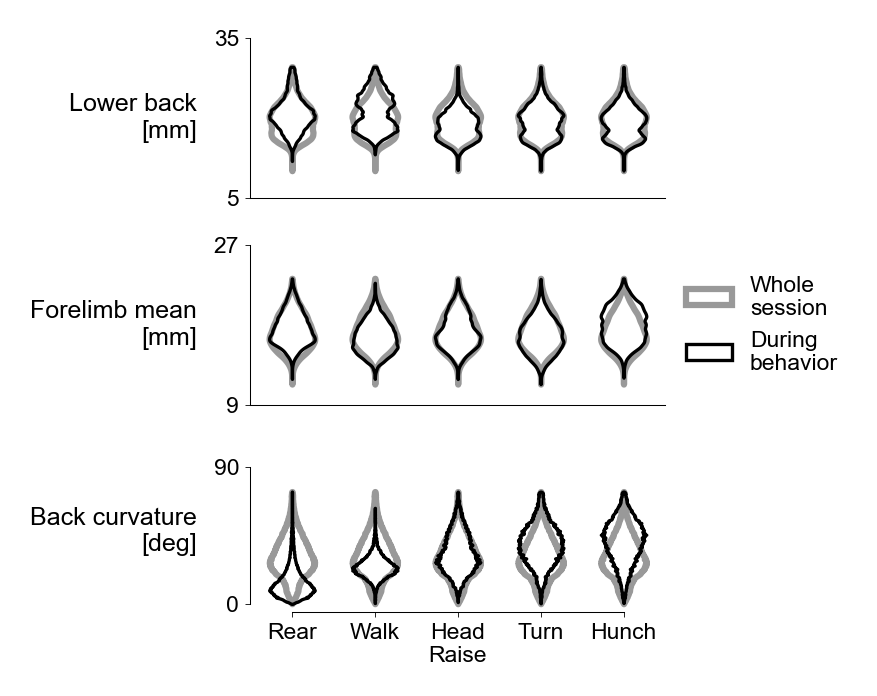

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/bone-bhv-examples-vert.pdf')

In [226]:
fig, ax = plt.subplots(3, 1, figsize=(2.3, 2.3), sharex=False, dpi=150)
# ax[1, 1].set_axis_off()
ax = ax.T.ravel()[[0, 1, 2]]

kws = dict(
    bw = 0.2,
    x = np.arange(len(plot_bhv)),
    errorbar = False,
    jitter = False,
    thumb_bandwidth = True,
    xticks = "",
    width=0.55,
    legend = False,
)

for i in range(3):
    vu.grouped_violins(
        [[bone_dists['none'][i][::subsample]] for b in plot_bhv],
        colors = '.6',
        fill_kw = dict(linewidth = 1.5),
        ax = ax[i],
        labels = 'Whole\nsession',
        **kws,
    )

    vu.grouped_violins(
        [[bone_dists[b][i][::subsample]] for b in plot_bhv],
        colors = 'k',
        ax = ax[i],
        labels = 'During\nbehavior',
        **kws
    )

    ax[i].set_xticks([])
    ax[i].spines['bottom'].set_visible(False)
    

ax[2].set_xticks(range(len(plot_bhv)))
ax[2].set_xticklabels([bhv_names[b] for b in plot_bhv])
vu.nticks(ax, 2, x = False)
vu.round_limits(ax, 0.6, x=False)
ax[2].set_ylim(-5, None)
ax[2].set_yticks([0, 90])

ax[0].set_ylabel("Lower back\n[mm]", rotation = 0, ha = 'right', va = 'center')
ax[1].set_ylabel("Forelimb mean\n[mm]", rotation = 0, ha = 'right', va = 'center')
ax[2].set_ylabel("Back curvature\n[deg]", rotation = 0, ha = 'right', va = 'center')

for a in ax:
    sns.despine(ax = a, trim = True)

fig.tight_layout()
vu.legend(ax[1], vu.unique_handles(ax[2]))

plotter.finalize(fig, 'bone-bhv-examples-vert', despine=False, tight=False)

### h. (experiment) Variance in *mean* IKD and JAs explained by behavior and age

In [192]:
session_order = [(s, i) for s in sessions for i in [0, 1]]
onehot = lambda n, i: np.array([0] * (i) + [1] + [0] * (n - i - 1))
bhv_order = list(bhv_keys.keys())
bls_mean = np.array([bl[s][half_slices[i]].mean(axis = 0) for (s, i) in session_order])
ages_onehot = np.array([onehot(len(ages), ages.index(re.search(r"(\d+)wk", s).group(1))) for (s, i) in session_order])
half_length = {s: [len(obs_keypts[s][half_slices[i]]) for i in range(2)] for s in sessions}
usage_fracs = np.array([[bhv_masks[k][s][half_slices[i]].sum() / half_length[s][i] for k in bhv_order] for (s, i) in session_order])

def calc_expl_var(X, Y, Xv, Yv):
    reg = LinearRegression().fit(X, Y)
    preds = reg.predict(Xv)
    errs = Yv - preds
    return errs.var(axis = 0) / Yv.var(axis = 0), preds

bhv_expl_var, bhv_preds = calc_expl_var(usage_fracs, bls_mean, usage_fracs, bls_mean)
age_expl_var, age_preds = calc_expl_var(ages_onehot, bls_mean, ages_onehot, bls_mean)

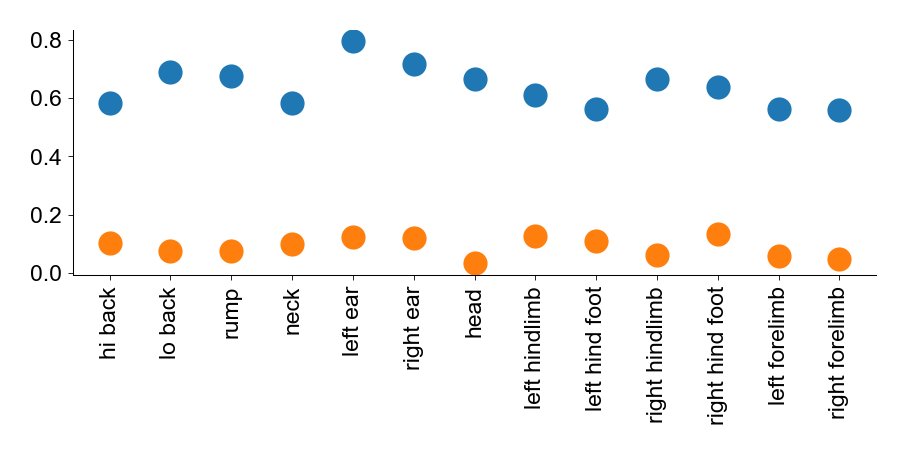

In [193]:
fig, ax = plt.subplots(1, 1, figsize = (3, 1.5), dpi = 150)
ax.plot(bhv_expl_var, 'o')
ax.plot(age_expl_var, 'o')
ax.set_xticks(np.arange(len(bhv_expl_var)))
ax.set_xticklabels(bone_names, rotation = 90)
plotter.finalize(fig, None)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (2, 1))

plotter.finalize(fig, None)

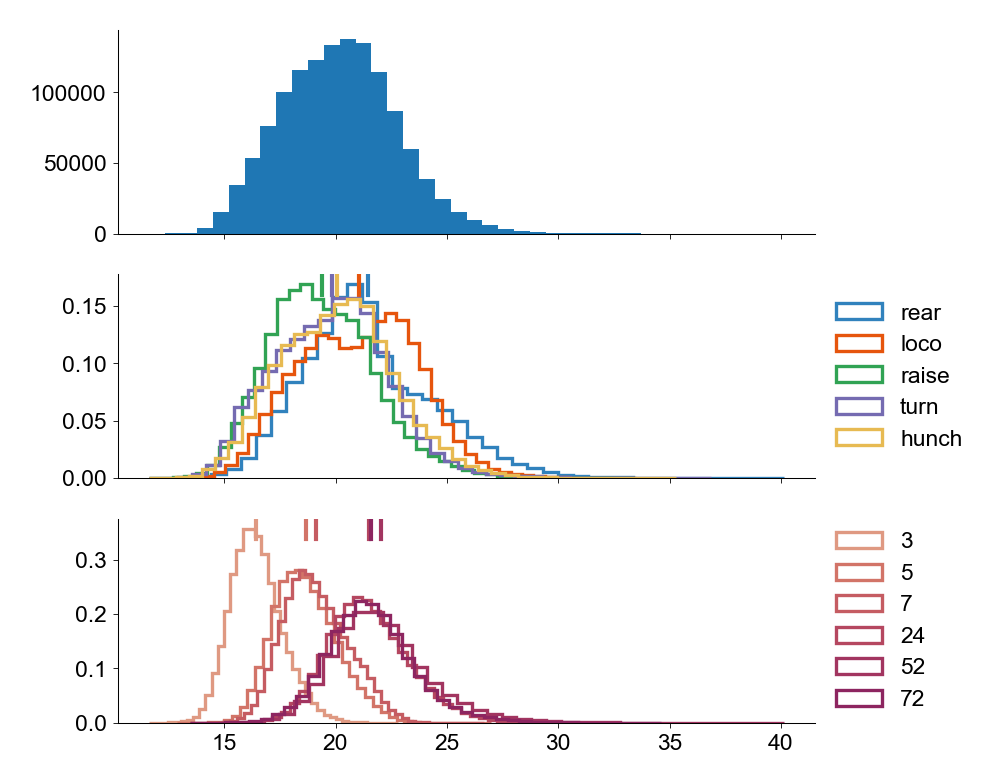

In [154]:
fig, ax = plt.subplots(3,1, figsize = (3, 3), sharex=True, dpi=150)
loback_ix = bone_names.index('lo back')
ax[0].hist(np.concatenate([bl[s][:, loback_ix] for s in sessions]), bins = 40)
for ib in range(5):
    k = bhv_order[ib]
    x = np.concatenate([bl[s][bhv_masks[k][s], loback_ix] for s in sessions])
    ax[1].hist(x, histtype='step', color = bhv_pal[k], bins = 40, label = k, density=True)
    ax[1].axvline(x.mean(), 0.9, 1, lw = 1, color = bhv_pal[k])
for ia, a in enumerate(ages):
    slist = [s for s in sessions if re.search(r"(\d+)wk", s).group(1) == a]
    x = np.concatenate([bl[s][:, loback_ix] for s in slist])
    ax[2].hist(x, histtype='step', color = age_pal[a], bins = 40, label = a,  density=True)
    ax[2].axvline(x.mean(), 0.9, 1, lw = 1, color = age_pal[a])
vu.legend(ax[1])
vu.legend(ax[2])

In [150]:
age_pal

{'3': Color((0.8727, 0.5999, 0.5082)),
 '5': Color((0.8237, 0.4532, 0.4087)),
 '7': Color((0.7744, 0.3621, 0.3826)),
 '24': Color((0.711, 0.2798, 0.3762)),
 '52': Color((0.6363, 0.2064, 0.3777)),
 '72': Color((0.5519, 0.1433, 0.3778))}

### h. Framewise variance explained by behavior and age

In [194]:
all_bl = np.concatenate([bl[s] for s in sessions])
all_masks = {
    k: np.concatenate([m[s] for s in sessions]) for k, m in list(bhv_masks.items())
}
bhv_pred_bls = mean_predictor(all_masks, all_bl)
cohort_bls = [np.concatenate([bl[s] for s in age_groups[a]]) for a in ages]
cohort_mask, cohort_y = concat_with_masks(cohort_bls)
cohort_pred_bls = mean_predictor(cohort_mask, cohort_y)
bhv_expl = expl_var(all_bl, bhv_pred_bls)
cohort_expl = expl_var(cohort_y, cohort_pred_bls)

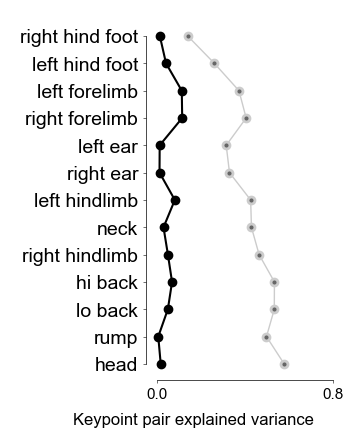

In [200]:
fig, ax = plt.subplots(1, 1, figsize=(1.8, 2.2))
sorting = np.argsort(bhv_expl - cohort_expl)
ax.plot(
    cohort_expl[sorting],
    np.arange(13),
    "-o",
    lw=0.5,
    ms=2.5,
    label="Age cohort",
    color='.8',
    markerfacecolor=vu.lighten('k', 0.4),
)
ax.plot(bhv_expl[sorting], np.arange(13), "-o", lw=0.75, ms=2.5, label="Behavior", color='k')
ax.set_yticks(np.arange(13))
ax.set_yticklabels([bone_names[i] for i in sorting], fontsize=7)
vu.nticks(ax, 2, y = False)
ax.set_xlim(-0.05, 0.8)
ax.set_xticks([0, 0.8])
sns.despine(ax = ax, trim = True)
ax.set_xlabel("Keypoint pair explained variance" + " " * 20)
# vu.legend(ax, loc = 'lower center', bbox_to_anchor = (0.3, 1), ncol = 2)

plotter.finalize(fig, None, despine = False)

In [214]:
all_ja = np.concatenate([ja[s] for s in sessions])
all_masks = {
    k: np.concatenate([m[s] for s in sessions]) for k, m in list(bhv_masks.items())
}
bhv_pred_jas = mean_predictor(all_masks, all_ja)
cohort_jas = [np.concatenate([ja[s] for s in age_groups[a]]) for a in ages]
cohort_mask, cohort_y = concat_with_masks(cohort_jas)
cohort_pred_jas = mean_predictor(cohort_mask, cohort_y)
bhv_expl_ja = expl_var(all_ja, bhv_pred_jas)
cohort_expl_ja = expl_var(cohort_y, cohort_pred_jas)

../../plots/notebook/panels/v4/f3.1_session-halves/bhv-age-expl-var-ja.pdf


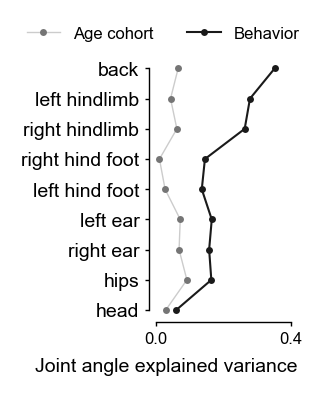

In [299]:
fig, ax = plt.subplots(1, 1, figsize=(1.65, 2))
sorting = np.argsort(bhv_expl_ja - cohort_expl_ja)
ax.plot(
    cohort_expl_ja[sorting],
    np.arange(9),
    "-o",
    lw=0.5,
    ms=2.5,
    label="Age cohort",
    color=colors.subtle,
    markerfacecolor=viz.util.lighten(colors.neutral, 0.4),
)
ax.plot(bhv_expl_ja[sorting], np.arange(9), "-o", lw=0.75, ms=2.5, label="Behavior", color=colors.neutral)
ax.set_yticks(np.arange(9))
ax.set_yticklabels([joint_names[i] for i in sorting], fontsize = 7)
vu.nticks(ax, 2, y = False)
ax.set_xlim(-0.02, 0.4)
ax.set_xticks([0, 0.4])
sns.despine(ax = ax, trim = True)
ax.set_xlabel("Joint angle explained variance" + " " * 20)
vu.legend(ax, loc = 'lower center', bbox_to_anchor = (0.1, 1), ncol = 2)

plotter.finalize(fig, 'bhv-age-expl-var-ja', save = True, transparent = True, despine = False)

#### debugging / another way to plot bahvior / age variance

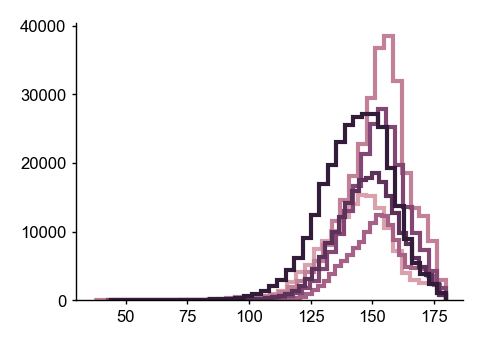

In [195]:
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.8))
for i in range(6):
    ax.hist((cohort_y)[cohort_mask[i] == 1, 0], histtype='step', color = colors.age_pal[ages[i]], lw = 1.5, bins = 40)

208.19539274058343 1.0529258585282735


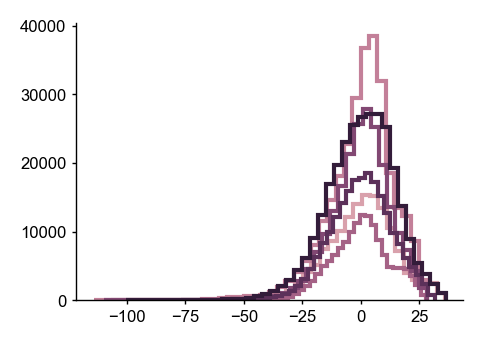

In [205]:
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.8))
j = 0
for i in range(6):
    x = (cohort_y - cohort_pred_jas)[cohort_mask[i] == 1, j]
    ax.hist(x, histtype='step', color = colors.age_pal[ages[i]], lw = 1.5, bins = 40)
x = (all_ja - cohort_pred_jas)[:, j]
print(x.var(), x.var() / all_ja[:, j].var())

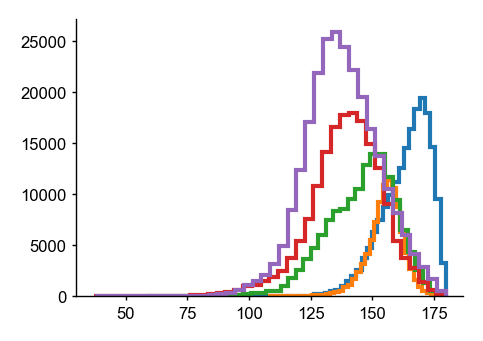

In [199]:
bhv_mask_arr = np.array(list(all_masks.values()))
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.8))
bhv_mask_arr = np.array(list(all_masks.values()))
for i in range(5):
    ax.hist(all_ja[bhv_mask_arr[i] == 1, 0], histtype='step', lw = 1.5, bins = 40)

128.19380511341745 0.6483264136168367


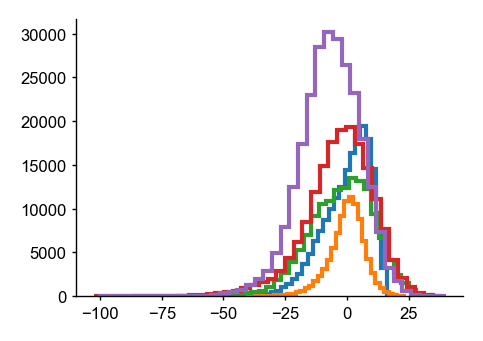

In [203]:
bhv_mask_arr = np.array(list(all_masks.values()))
fig, ax = plt.subplots(1, 1, figsize=(2.5, 1.8))
bhv_mask_arr = np.array(list(all_masks.values()))
j = 0
for i in range(5):
    x = (all_ja - bhv_pred_jas)[bhv_mask_arr[i] == 1, j]
    ax.hist(x, histtype='step', lw = 1.5, bins = 40)
x = (all_ja - bhv_pred_jas)[:, j]
print(x.var(), x.var() / all_ja[:, j].var())

### i. Time courses of inter keypoint distances and nose-to tail

/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


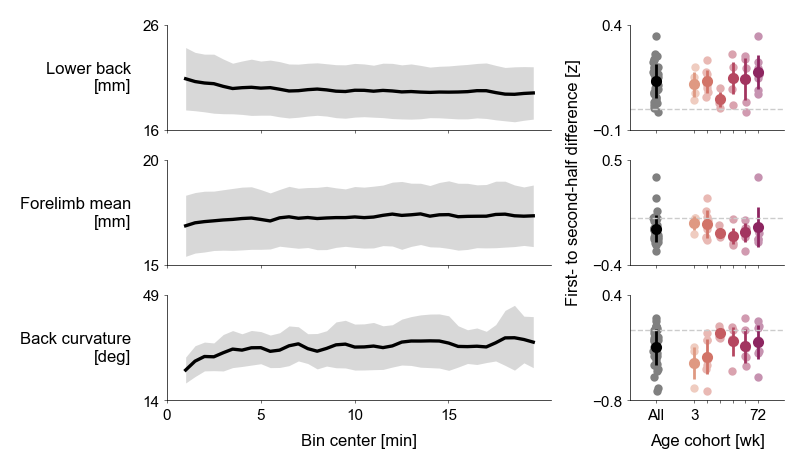

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v5/f3.1_session-halves/timecourses-bl-jas.pdf')

In [224]:
plot_sess = ["24wk_m4"]
lighten = [0.5, 0.5]
linewidth = [1.2, 1]

fig, ax = plt.subplots(3, 2, figsize=(4, 2.3), width_ratios=[2.5, 1])
summ_ax = ax[:, 1]
time_ax = ax[:, 0]

loback_ix = bone_names.index('lo back')
flmean_ix = [bone_names.index('left forelimb'), bone_names.index('right forelimb')]
backext_ix = joint_names.index('back')

ax = time_ax
for i, (s, lt, lw) in enumerate(zip(plot_sess, lighten, linewidth)):
    l = sessions
    lob = [bl[s][:min_nframes, loback_ix] for s in l]
    flm = [bl[s][:min_nframes, flmean_ix].mean(axis = -1) for s in l]
    bex = [180 - ja[s][:min_nframes, backext_ix] for s in l]
    a = s.split("_")[0].rstrip("wk")

    rolling_line(ax[0], frame_times, lob, 1800, 'k', lt, lw=lw)
    rolling_line(ax[1], frame_times, flm, 1800, 'k', lt, lw=lw)
    rolling_line(ax[2], frame_times, bex, 1800, 'k', lt, lw=lw)

for a in ax:
    a.set_xticks([0, 5, 10, 15])
for a in ax[:-1]:
    a.set_xticklabels(["", "", "", ""])
vu.nticks(ax, 2, x=False)
vu.round_limits(ax, 0.6, x=False)

ax[0].set_ylabel("Lower back\n[mm]", rotation = 0, ha = 'right', va = 'center')
ax[1].set_ylabel("Forelimb mean\n[mm]", rotation = 0, ha = 'right', va = 'center')
ax[2].set_ylabel("Back curvature\n[deg]", rotation = 0, ha = 'right', va = 'center')
ax[-1].set_xlabel("Bin center [min]")

ax = summ_ax
half_zdiff = (
    lambda data, ix, sign=1: lambda s: zscore_dict(pull_ix(data, ix), sign)[s][half_slices[0]].mean()
    - zscore_dict(pull_ix(data, ix), sign)[s][half_slices[1]].mean()
)
normalize = lambda d, mean, std: {k: (v - mean) / std for k, v in d.items()}
zscore_dict = lambda d, sign=1: normalize(d, np.mean(np.concatenate(list(d.values()))), sign * np.std(np.concatenate(list(d.values()))))
pull_ix = lambda d, ix: {k: a[:, ix].mean(axis = -1) for k, a in d.items()}


for i, (data, ix, sgn) in enumerate(zip([bl, bl, ja], [[loback_ix], flmean_ix, [backext_ix]], [1, 1, -1])):
    group_and_summary_strips(
        ax[i],
        half_zdiff(data, ix, sgn),
        groups=age_groups,
        order=ages,
        all_keys=sessions,
        summary_color='k',
        group_colors=age_pal,
        x_ofs=3,
    )

for a in ax:
    a.axhline(0, color='.8', lw=0.5, ls="--")

ax[-1].set_xticklabels(["All"] + [ages[0]] + [""] * (len(ages) - 2) + [ages[-1]])
vu.nticks(ax, 2, x=False)
vu.round_limits(ax, 0.6, x=False)
ax[0].set_ylabel("First- to second-half difference [z]" + " " * 45, ha="center")
ax[-1].set_xlabel("Age cohort [wk]")

plotter.finalize(fig, 'timecourses-bl-jas', despine = False)